In [1]:

import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
import os
import seaborn as sns
import matplotlib.pyplot as plt
# from logic_features import GenerateFeatures
from acc_gyr_features import GenerateFeatures
from essentials import two_class_labels, normalize, preprocess_data, preprocess_data_separate_acc_gravity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import plotly.express as px
import plotly.graph_objects as go
import copy

In [2]:
with open('data/df_dict_imu.pkl', 'rb') as f:
    imu_dict = pickle.load(f)
with open('data/df_dict_urineestimate_method1.pkl', 'rb') as f:
    urine_estimates_dict = pickle.load(f)
with open('data/df_minze_dict.pkl', 'rb') as f:
    ground_truth_dict = pickle.load(f)

Pre-process the data to see if the performance improves.

1. Apply a median filter
2. Apply Butterworth Low-Pass (20Hz cutoff)

Both to remove noise

In [3]:
preprocessed_dict = {}
dict = copy.deepcopy(imu_dict)
for i_void_instance, void_instance in tqdm(enumerate(dict.keys()), desc="Preprocessing data"):
    acc = dict[void_instance]
    
    # preprocessed_data = preprocess_data(acc)
    preprocessed_data = preprocess_data_separate_acc_gravity(acc)

    preprocessed_dict[void_instance] = preprocessed_data

Preprocessing data: 18it [00:00, 176.46it/s]

Preprocessing data: 43it [00:00, 159.99it/s]


In [4]:
labelled_imu_dict = {}
dict = copy.deepcopy(imu_dict)
# dict = copy.deepcopy(preprocessed_dict)
for i_void_instance, void_instance in tqdm(enumerate(dict.keys()), desc="Adding labels to IMU data"):
    acc = dict[void_instance]
    gt = ground_truth_dict[void_instance]
    
    # # normalize data
    df = normalize(acc)
    
    # add the labels
    labelled_df = two_class_labels(acc, gt)
    
    # remove the gyr data
    # labelled_df.drop(columns=['gyr_x', 'gyr_y', 'gyr_z'], axis = 1)
    labelled_imu_dict[void_instance] = labelled_df

Adding labels to IMU data: 43it [00:00, 290.33it/s]


In [5]:
# I changed the overlap to 0.5

all_features = []
#  do not upsample
features_per_experiment = {}
for exp_id, imu_data in enumerate(imu_dict.keys()):    
    # Extract features
    
    df = labelled_imu_dict[imu_data]
    fs = 1 / df['time'].diff().median()
    analyzer = GenerateFeatures(fs, window_duration=2.0, overlap=0.8)
    features, _ = analyzer.analyze_multi_axis_imu(labelled_imu_dict[imu_data])

    table = analyzer.create_summary_table()
    table['experiment_id'] = exp_id + 1  # Track source
    all_features.append(table)
    
    
    features_per_experiment[imu_data] = table
final_features = pd.concat(all_features, ignore_index=True)

Analyzing : 100%|██████████| 8/8 [00:01<00:00,  5.86it/s]


In [37]:
final_features.to_csv('feature_based_data/two_class_raw_2s_0.8_logic.csv', index=False)
final_features.shape

(6203, 93)

In [7]:
# plot the confusion matrix
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))
    cm_df = pd.DataFrame(cm, index=sorted(set(y_true)), columns=sorted(set(y_true)))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [8]:
# individual_experiment = features_per_experiment['subj_15_void1']

In [ ]:
# Parameters
N = 5 / 0.5 # number of consecutive frames needed to enter VOID
M = 3 / 0.5 # number of consecutive violations to exit VOID

# Initialize
state = 'NON_VOID'
void_buffer = 0
non_void_buffer = 0
void_state_duration = 0
preds = []

# Iterate through data
for idx, row in final_features.iterrows():

    # Define your void condition
    void_condition = (
        (row['acc_x_var'] <= 0.5) and 
        (row['acc_y_var'] <= 0.5) and 
        (row['acc_z_var'] <= 0.5)
    )
    # is_low_var = (row['acc_x_var'] <= 1) and (row['acc_y_var'] <= 0.5) and (row['acc_z_var'] <= 0.5)
    # is_mean_posture = (-0.6 <= row['acc_x_mean'] <= 1) and (-1 <= row['acc_y_mean'] <= 0) and (-1 <= row['acc_z_mean'] <= 0)

    # void_condition = is_low_var and is_mean_posture

    if state == 'NON_VOID':
        void_state_duration = 0  # reset
        if void_condition:
            void_buffer += 1
            if void_buffer >= N:
                state = 'VOID'
                void_buffer = 0
        else:
            void_buffer = 0
        preds.append('non-void')

    elif state == 'VOID':
        void_state_duration += 1

        # Early exit if VOID state runs too long
        if void_state_duration > (30 / 0.5):
            state = 'NON_VOID'
            non_void_buffer = 0
            preds.append('non-void')
            continue

        if not void_condition:
            non_void_buffer += 1
            if non_void_buffer >= M:
                state = 'NON_VOID'
                non_void_buffer = 0
                void_state_duration = 0
        else:
            non_void_buffer = 0

        preds.append('void')

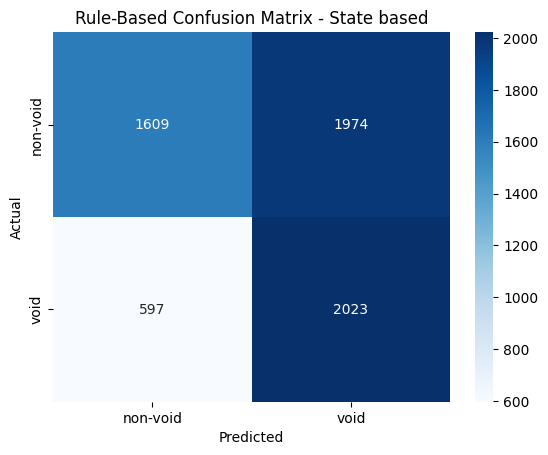

In [10]:
y_true = np.array(final_features['label'])
plot_confusion(y_true, preds, "Rule-Based Confusion Matrix - State based")

In [12]:
def extract_void_segments(df, N_seconds=5, M_seconds=3, max_void_duration_seconds=50):
    window_advance_time = 0.5  # 1s window, 0.5 overlap → 0.5s per row
    N = int(N_seconds / window_advance_time)  # N=10 for 5s
    M = int(M_seconds / window_advance_time)  # M=6 for 3s
    max_void_duration = int(max_void_duration_seconds / window_advance_time)  # 70 for 35s

    state = 'NON_VOID'
    void_buffer = 0
    non_void_buffer = 0
    void_state_duration = 0
    terminated = False  # Flag to block re-entry after forced exit

    preds = []
    void_segments = []
    void_start = None

    for idx, row in df.iterrows():
        if terminated:
            preds.append('non-void')  # Force non-void after termination
            continue
        
        # is_low_var = (-0.5 <= row['acc_x_var'] <= 1) and (-0.5 <= row['acc_y_var'] <= 0.5) and (-0.5 <= row['acc_z_var'] <= 0.5)
        # is_mean_posture = (-0.6 <= row['acc_x_mean'] <= 1) and (-1 <= row['acc_y_mean'] <= 0) and (-1 <= row['acc_z_mean'] <= 0)

        
        # void_condition = is_low_var and is_mean_posture

        void_condition = (
            (row['acc_x_var'] <= 0.5) and 
            (row['acc_y_var'] <= 0.5) and 
            (row['acc_z_var'] <= 0.5)
        )
        
        # void_condition = row['acc_x_var'] + row['acc_y_var'] + row['acc_z_var'] < 1.5

        if state == 'NON_VOID':
            void_state_duration = 0
            if void_condition:
                void_buffer += 1
                if void_buffer >= N:
                    state = 'VOID'
                    void_buffer = 0
                    void_start = idx
            else:
                void_buffer = 0
            preds.append('non-void')

        elif state == 'VOID':
            void_state_duration += 1

            # Forced exit if max duration exceeded
            if void_state_duration > max_void_duration:
                state = 'NON_VOID'
                non_void_buffer = 0
                void_segments.append((void_start, idx))
                void_start = None
                preds.append('non-void')
                terminated = True  # Block future VOID states
                continue

            if not void_condition:
                non_void_buffer += 1
                if non_void_buffer >= M:
                    state = 'NON_VOID'
                    non_void_buffer = 0
                    void_segments.append((void_start, idx))
                    void_start = None
            else:
                non_void_buffer = 0
                void_segments.append((void_start, idx))

            preds.append('void')

    df = df.copy()
    df['state_machine_pred'] = preds
    if len(void_segments) == 0:
        return df, [0,0]
    else:
        return df, void_segments[-1]

In [38]:
test_experiment_ids = final_features['experiment_id'].unique()
all_preds = []
for exp_id in test_experiment_ids:
    exp_df = final_features[final_features['experiment_id'] == exp_id]
    df, void_segment = extract_void_segments(exp_df, N_seconds=5, M_seconds=3, max_void_duration_seconds=40)
    all_preds.extend(df['state_machine_pred'].tolist())

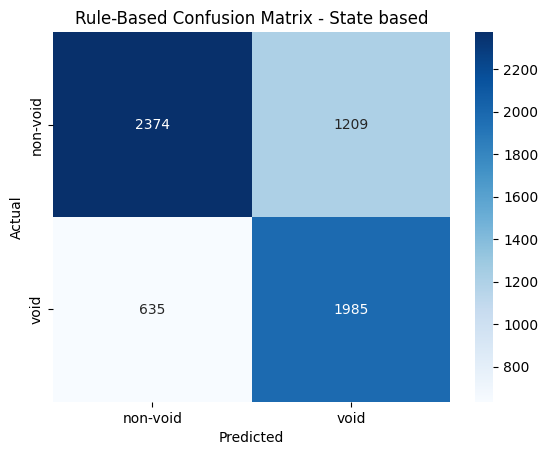

In [41]:
y_true = np.array(final_features['label'])
plot_confusion(y_true, all_preds, "Rule-Based Confusion Matrix - State based")

In [13]:
# sig = features_per_experiment['subj_3_void8']
# raw_imu = imu_dict['subj_3_void8']
# gt = ground_truth_dict['subj_3_void8']
# ue = urine_estimates_dict['subj_3_void8']


# # sig = sig.loc[:, ~sig.columns.str.contains('_energy$|_min$|_max$|_entropy$|mag')]  # Drops columns starting with 'user'
# sig = sig.loc[:, ~sig.columns.str.contains('_min$|_max$|mag')]  # Drops columns starting with 'user'
# sig.head()

,center_time,start_time,end_time,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,...,gyr_z_spectral_entropy,gyr_z_mean,gyr_z_std,gyr_z_range,gyr_z_rms,gyr_z_var,gyr_z_time_energy,gyr_z_spectral_energy,label,experiment_id
0,0.992527,0.000000,1.985054,0.818411,0.678019,-0.964277,0.710282,3.081282,1.197636,0.504500,...,0.587891,-1.450683,1.318782,4.651603,1.960527,1.739185,461.239973,55348.796816,non-void,20
1,1.372996,0.380469,2.365523,0.864334,0.653747,-1.246672,0.667588,3.226253,1.414166,0.445673,...,0.632471,-1.326000,1.362351,4.651603,1.901125,1.856000,433.713033,52045.563918,non-void,20
2,1.753465,0.760937,2.745992,0.877686,0.656895,-1.529026,0.487642,2.188026,1.604904,0.237795,...,0.643903,-0.756545,1.144322,4.177019,1.371800,1.309473,225.820099,27098.411882,non-void,20
3,2.133933,1.141406,3.126461,0.867164,0.629383,-1.756088,0.436152,2.497632,1.809441,0.190229,...,0.586571,-0.682286,1.057953,4.177019,1.258880,1.119264,190.173386,22820.806339,non-void,20
4,2.514402,1.521875,3.506929,0.869962,0.615197,-1.858519,0.350908,1.554574,1.891357,0.123136,...,0.521224,-0.069988,0.732619,3.033120,0.735955,0.536731,64.995547,7799.465699,non-void,20


In [11]:
# def extract_void_segments(df, N_seconds=5, M_seconds=3, max_void_duration_seconds=35):
#     window_advance_time = 0.5  # 1s window, 0.8 overlap
#     N = int(N_seconds / window_advance_time)  # N=25 for 5s
#     M = int(M_seconds / window_advance_time)  # M=15 for 3s
#     max_void_duration = int(max_void_duration_seconds / window_advance_time)  # 200 for 40s
    
#     """
#     Detects void segments using a state machine based on acceleration variance.
    
#     Parameters:
#     - df: pandas DataFrame with acc_x_var, acc_y_var, acc_z_var columns
#     - N: number of consecutive void-like frames to enter VOID state
#     - M: number of consecutive non-void frames to exit VOID state
#     - max_void_duration: maximum length of VOID state before forced exit

#     Returns:
#     - updated_df: original DataFrame with a 'state_machine_pred' column
#     - void_segments: list of (start_index, end_index) for void segments
#     """
#     state = 'NON_VOID'
#     void_buffer = 0
#     non_void_buffer = 0
#     void_state_duration = 0

#     preds = []
#     void_segments = []
#     void_start = None

#     for idx, row in df.iterrows():
#         void_condition = (
#             (row['acc_x_var'] <= 1) and 
#             (row['acc_y_var'] <= 0.5) and 
#             (row['acc_z_var'] <= 0.5)
#         )
        
#         # void_condition = (
#         #     (row['acc_x_var'] <= df['acc_x_var'].quantile(0.1)) and  # Use percentile-based thresholds
#         #     (row['acc_y_var'] <= df['acc_y_var'].quantile(0.1)) and
#         #     (row['acc_z_var'] <= df['acc_z_var'].quantile(0.1))
#         # )

#         if state == 'NON_VOID':
#             void_state_duration = 0
#             if void_condition:
#                 void_buffer += 1
#                 if void_buffer >= N:
#                     state = 'VOID'
#                     void_buffer = 0
#                     void_start = idx
#             else:
#                 void_buffer = 0
#             preds.append('non-void')

#         elif state == 'VOID':
#             void_state_duration += 1

#             # Forced exit
#             if void_state_duration > max_void_duration:
#                 state = 'NON_VOID'
#                 non_void_buffer = 0
#                 void_segments.append((void_start, idx))
#                 void_start = None
#                 preds.append('non-void')
#                 continue

#             if not void_condition:
#                 non_void_buffer += 1
#                 if non_void_buffer >= M:
#                     state = 'NON_VOID'
#                     non_void_buffer = 0
#                     void_segments.append((void_start, idx))
#                     void_start = None
#                     void_state_duration = 0
#             else:
#                 non_void_buffer = 0

#             preds.append('void')

#     # Assign predictions to DataFrame
#     df = df.copy()
#     df['state_machine_pred'] = preds
#     return df, void_segments

In [14]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_var", "acc_y_var", "acc_z_var"], 
#                 title=f"Signal var")
# fig.show()

In [15]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_range", "acc_y_range", "acc_z_range"], 
#                 title=f"Signal range")
# fig.show()

In [16]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_std", "acc_y_std", "acc_z_std"], 
#                 title=f"Signal std")
# fig.show()

In [17]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_rms", "acc_y_rms", "acc_z_rms"], 
#                 title=f"Signal rms")
# fig.show()

In [18]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_spectral_entropy", "acc_y_spectral_entropy", "acc_z_spectral_entropy"], 
#                 title=f"Signal spectral_entropy")
# fig.show()

In [19]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_permutation_entropy", "acc_y_permutation_entropy", "acc_z_permutation_entropy"], 
#                 title=f"Signal permutation_entropy")
# fig.show()

In [20]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_time_energy", "acc_y_time_energy", "acc_z_time_energy"], 
#                 title=f"Signal time_energy")
# fig.show()

In [21]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_spectral_energy", "acc_y_spectral_energy", "acc_z_spectral_energy"], 
#                 title=f"Signal spectral_energy")
# fig.show()

In [22]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["gyr_x_var", "gyr_y_var", "gyr_z_var"], 
#                 title=f"Signal gyr var")
# fig.show()

In [36]:
# fig = px.scatter(sig, x="center_time", 
#                 y=["gyr_x_spectral_energy", "gyr_y_spectral_energy", "gyr_z_spectral_energy"], 
#                 title=f"Signal gyr spectral_energy")
# fig.show()

Using the void segments as the index to find the start and end time.

void_segment[0] - start time

void_segment[1] - end time

In [ ]:
# start_time = sig['start_time'][void_segment[0]]
# end_time = sig['end_time'][void_segment[1]]
# # start_time

KeyError: 219

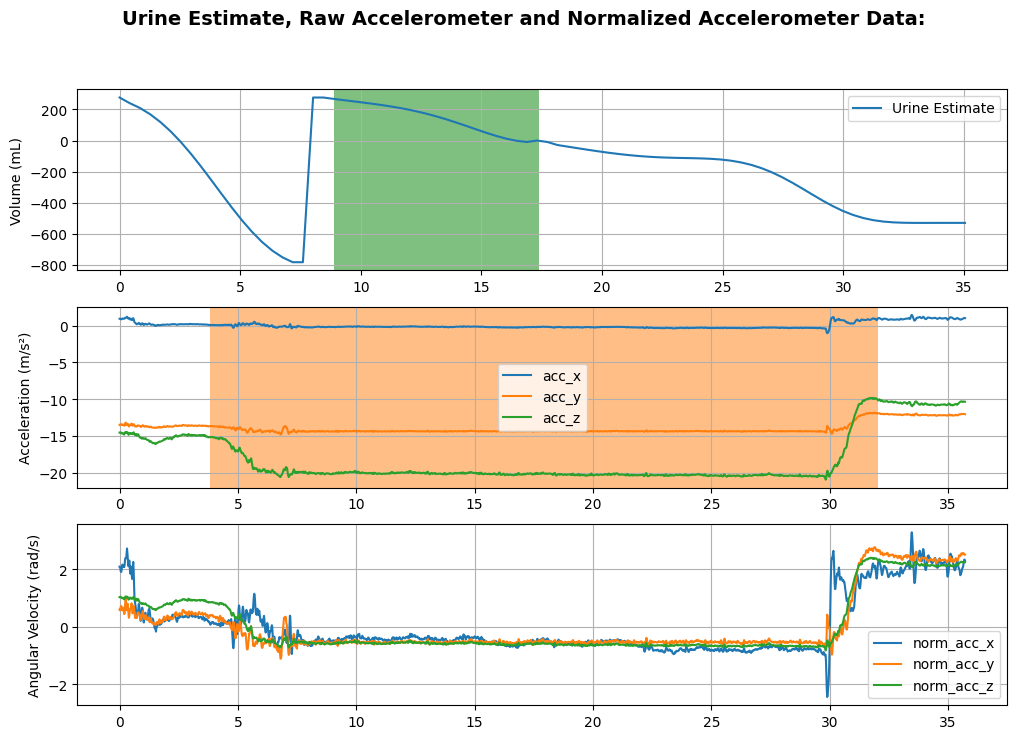

In [ ]:
# # Urination event is the first and last time of the ground truth data
# urination_event = [gt['Time'].iloc[0], gt['Time'].iloc[-1]] 
# # Standardize IMU data
# acc_x_norm = (raw_imu['acc_x'] - raw_imu['acc_x'].mean()) / raw_imu['acc_x'].std()
# acc_y_norm = (raw_imu['acc_y'] - raw_imu['acc_y'].mean()) / raw_imu['acc_y'].std()
# acc_z_norm = (raw_imu['acc_z'] - raw_imu['acc_z'].mean()) / raw_imu['acc_z'].std()


# # Create a figure with 2 subplots (shared x-axis)
# fig, (ax_top, ax_bottom, ax_middle) = plt.subplots(3, 1, figsize=(12, 8))
# fig.suptitle(f'Urine Estimate, Raw Accelerometer and Normalized Accelerometer Data: ', fontsize=14, fontweight='bold')


# # --- Top subplot: Urine Estimate ---
# ax_top.plot(ue['Time'], ue['UrineEstimate'], label='Urine Estimate')
# # ax_top.plot(ground_truth['Time'], ground_truth['Volume'], label='Ground Truth')

# ax_top.axvspan(urination_event[0], urination_event[1], facecolor='green', alpha=0.5)
# ax_top.set_ylabel('Volume (mL)')
# # ax_top.set_title(f'Urine Estimate and IMU Data for {void_instance}')

# ax_top.legend(loc='best')
# ax_top.grid(True)

# # --- Bottom subplot: Accelerometer and Gyroscope ---
# # Accelerometer
# ax_bottom.plot(raw_imu['time'], raw_imu['acc_x'], label='acc_x')
# ax_bottom.plot(raw_imu['time'], raw_imu['acc_y'], label='acc_y')
# ax_bottom.plot(raw_imu['time'], raw_imu['acc_z'], label='acc_z')
# ax_bottom.axvspan(start_time, end_time, facecolor='tab:orange', alpha=0.5)
# ax_bottom.set_ylabel('Acceleration (m/s²)')
# ax_bottom.legend(loc='best')
# ax_bottom.grid(True)

# # Gyroscope (second y-axis)
# # ax2 = ax_bottom.twinx()
# ax_middle.plot(raw_imu['time'], acc_x_norm, label='norm_acc_x')
# ax_middle.plot(raw_imu['time'], acc_y_norm, label='norm_acc_y')
# ax_middle.plot(raw_imu['time'], acc_z_norm, label='norm_acc_z')
# ax_middle.set_ylabel('Angular Velocity (rad/s)')
# ax_middle.legend(loc='best')
# ax_middle.grid(True)



    


In [ ]:
# df, void_segment = extract_void_segments(final_features, N_seconds=5, M_seconds=3, max_void_duration_seconds=40)
# preds = np.array(df['state_machine_pred'])
# y_true = np.array(final_features['label'])
# plot_confusion(y_true, preds, "Rule-Based Confusion Matrix - State based")

/tmp/ipykernel_20766/937276056.py:22: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



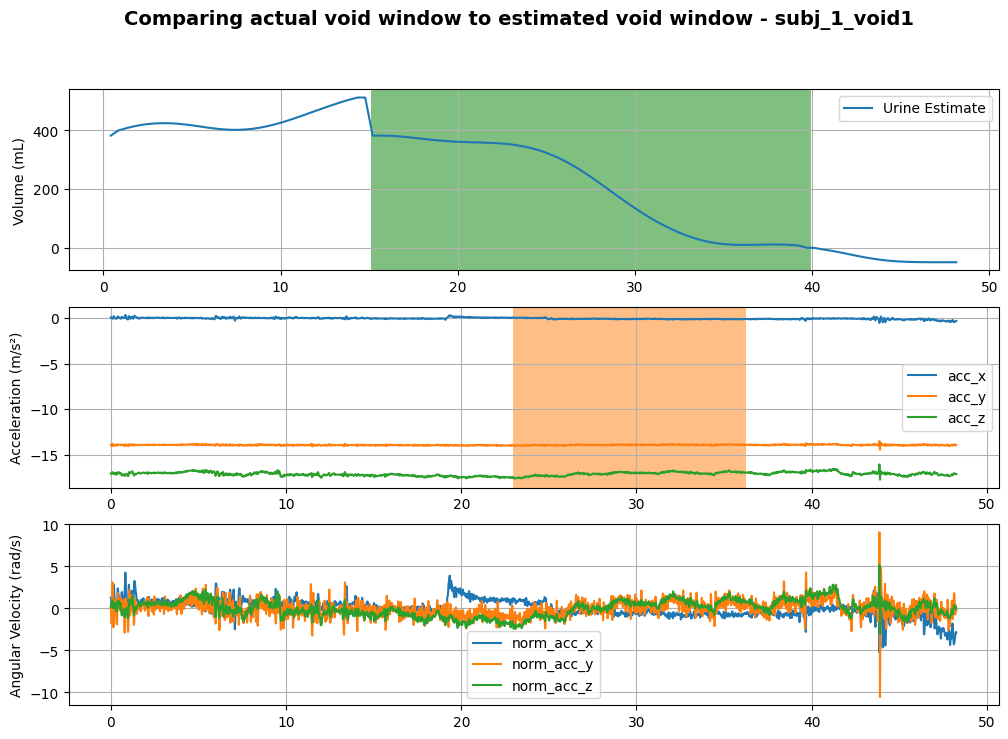

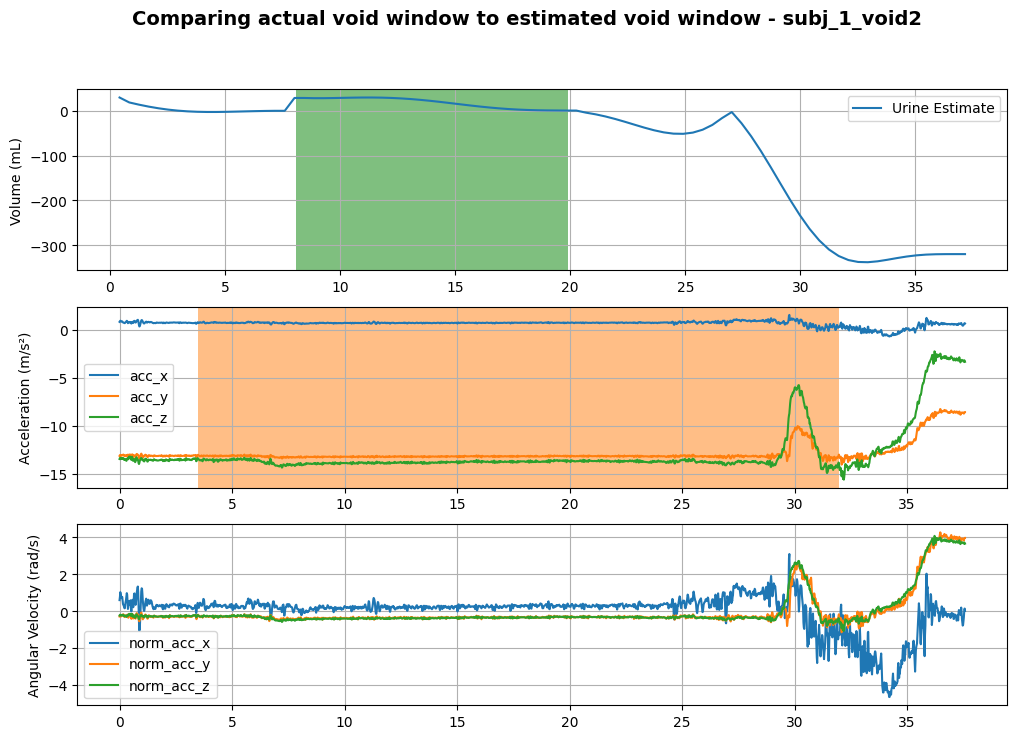

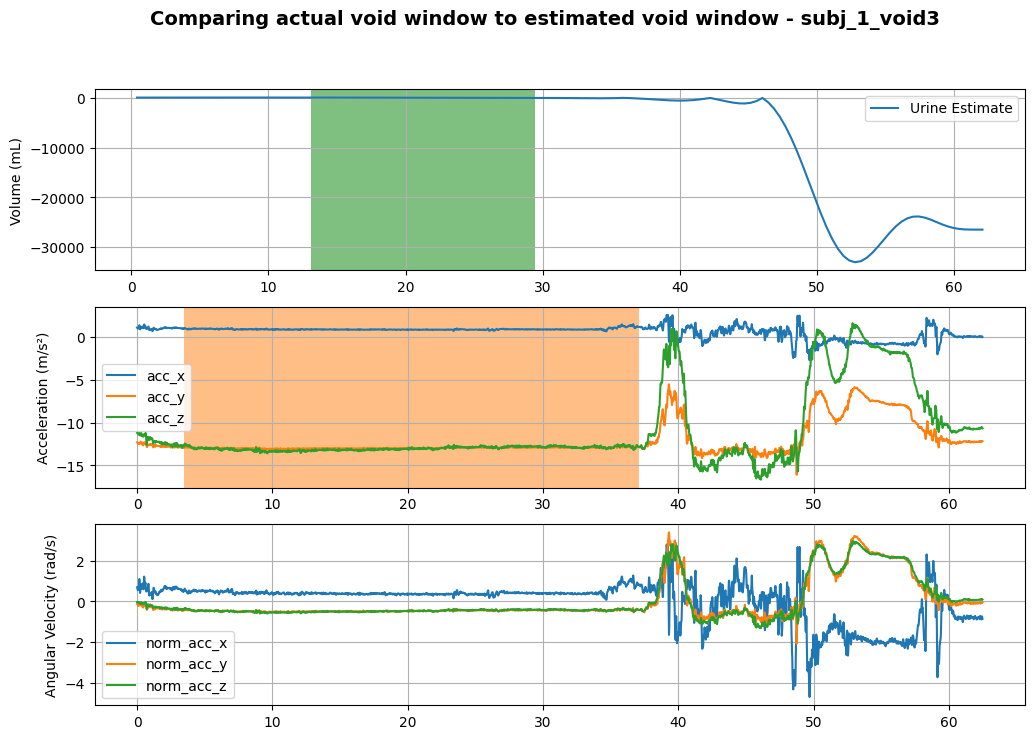

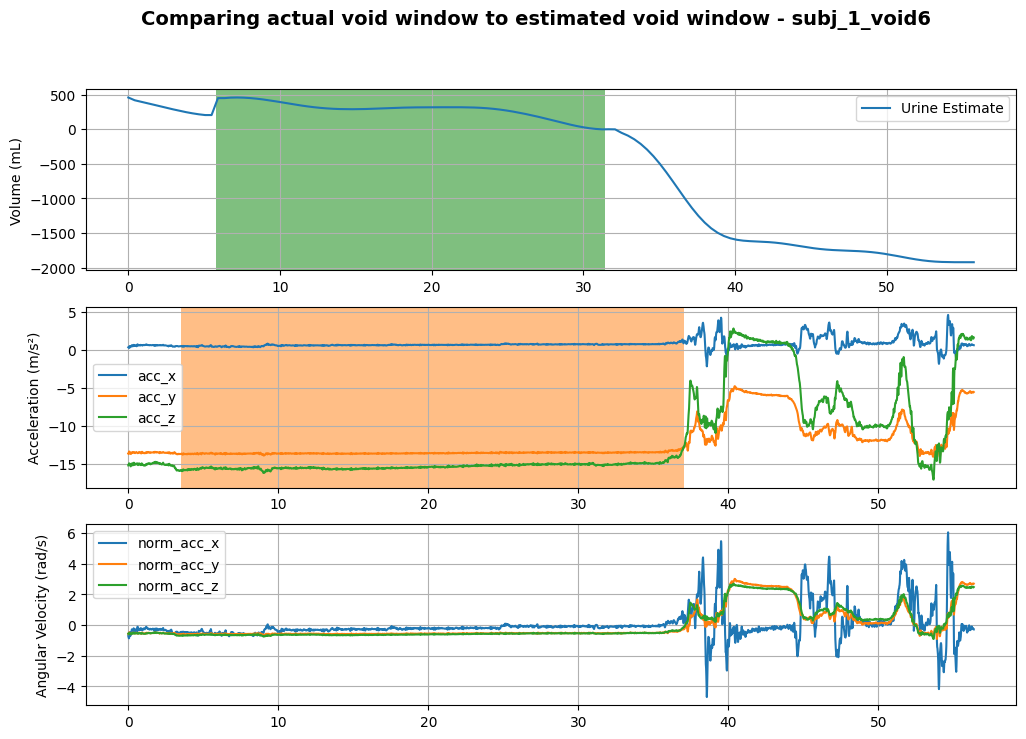

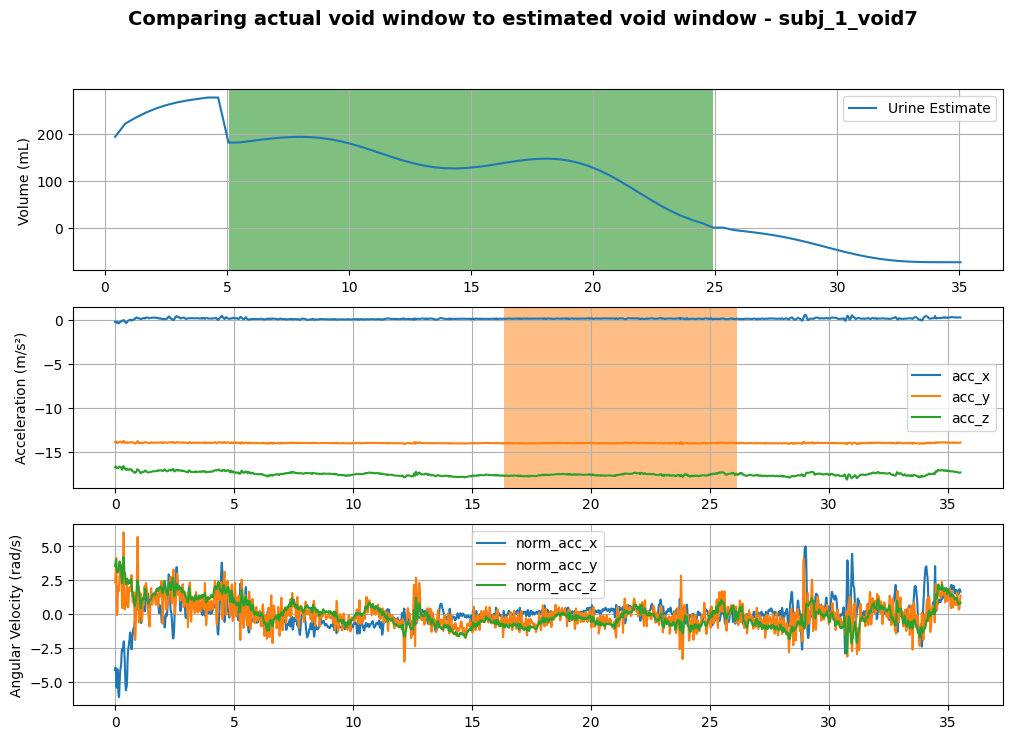

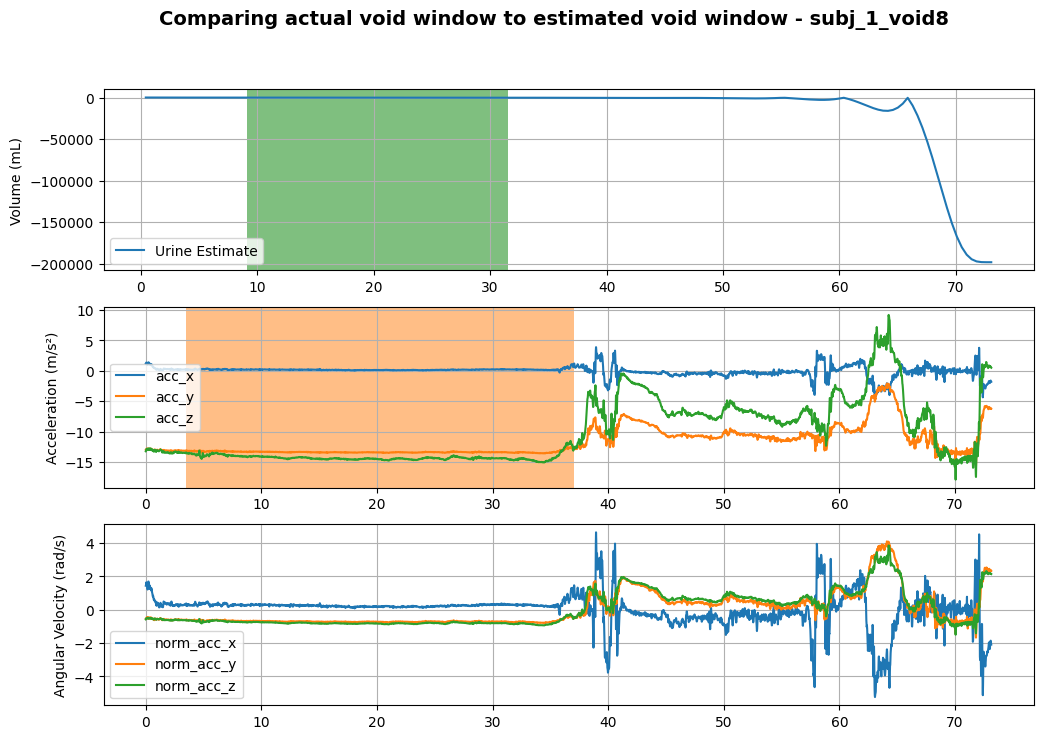

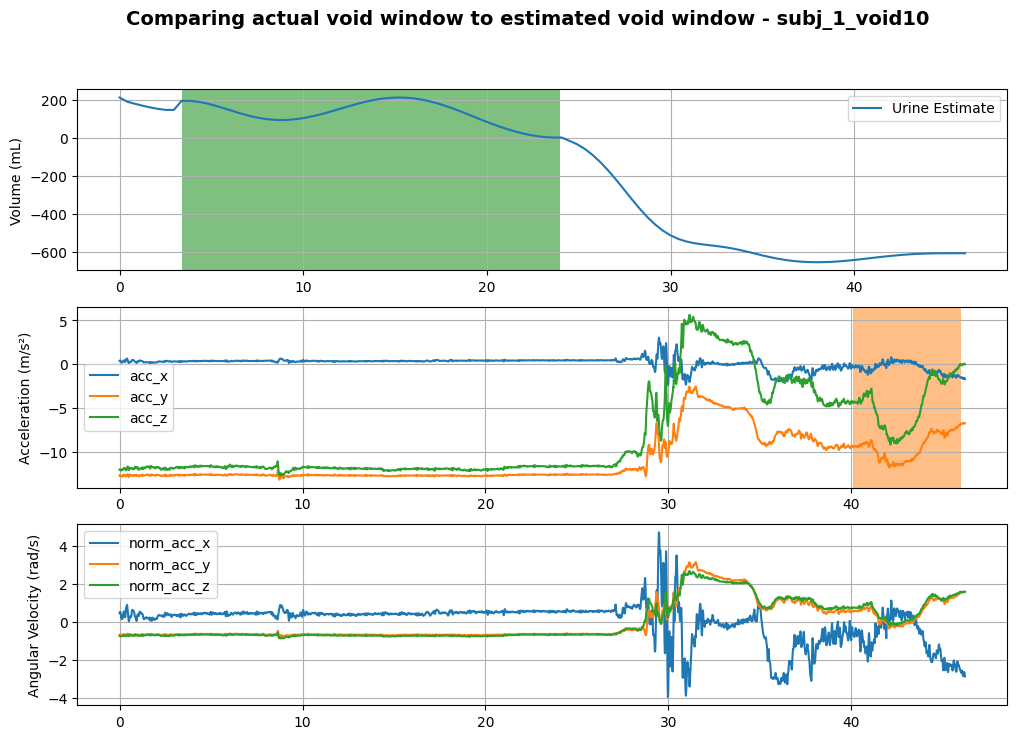

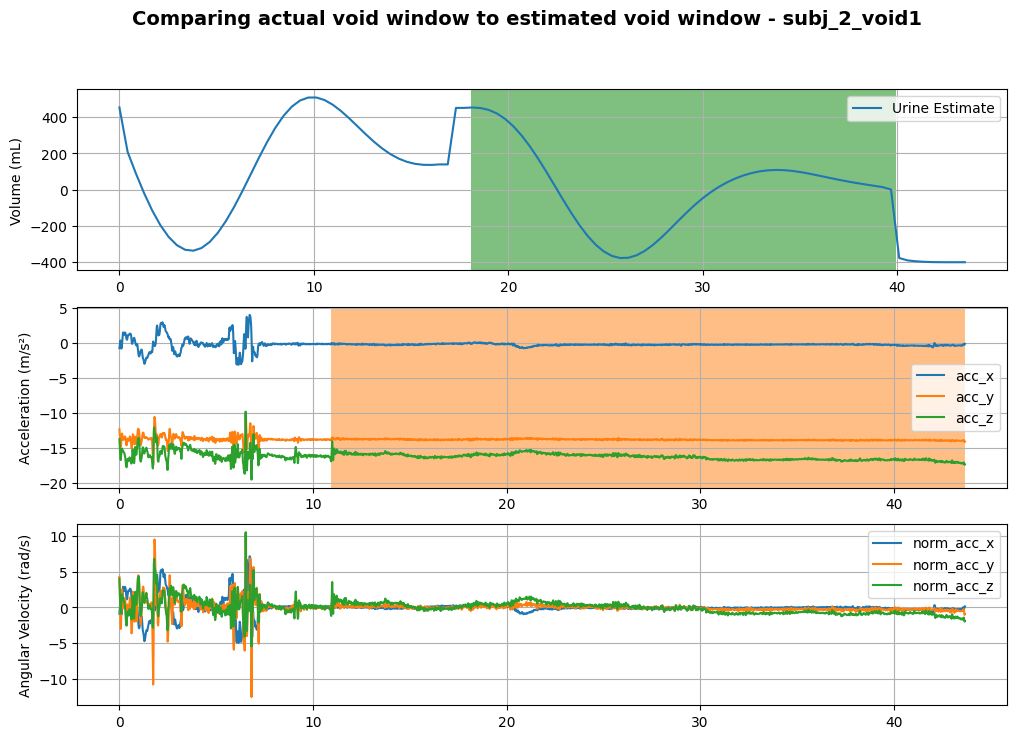

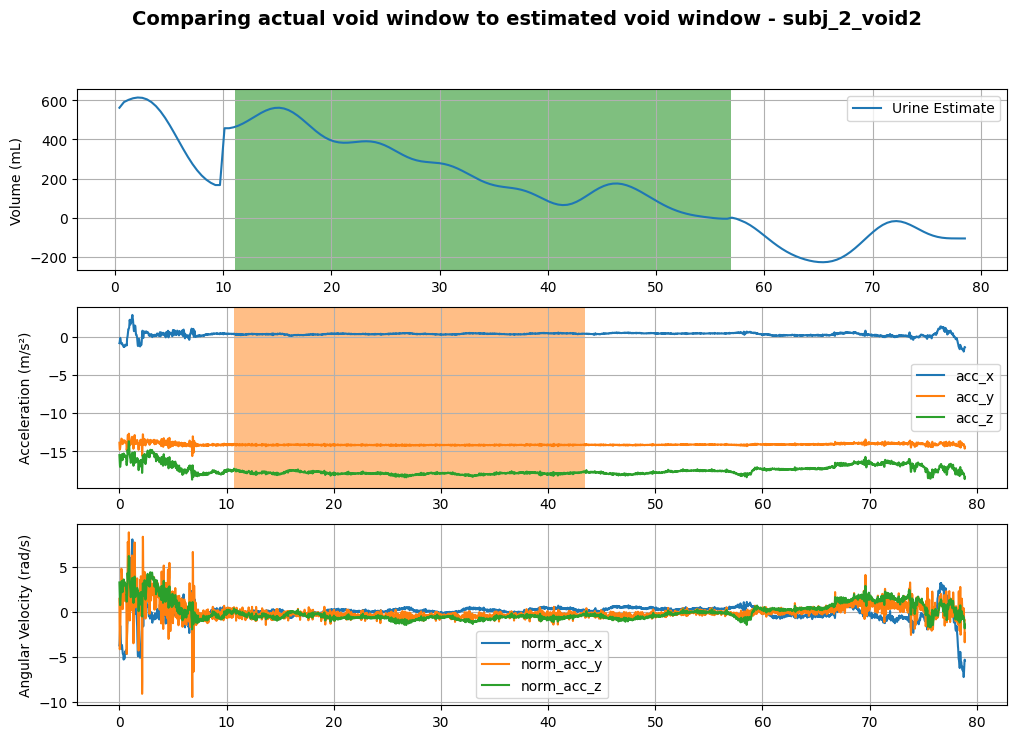

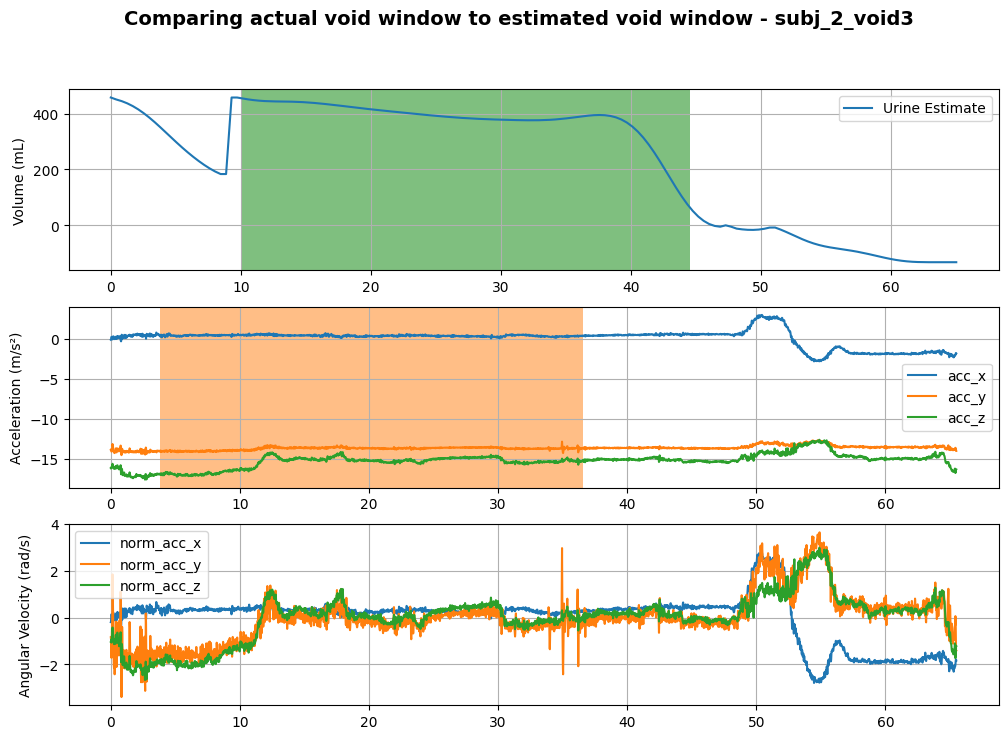

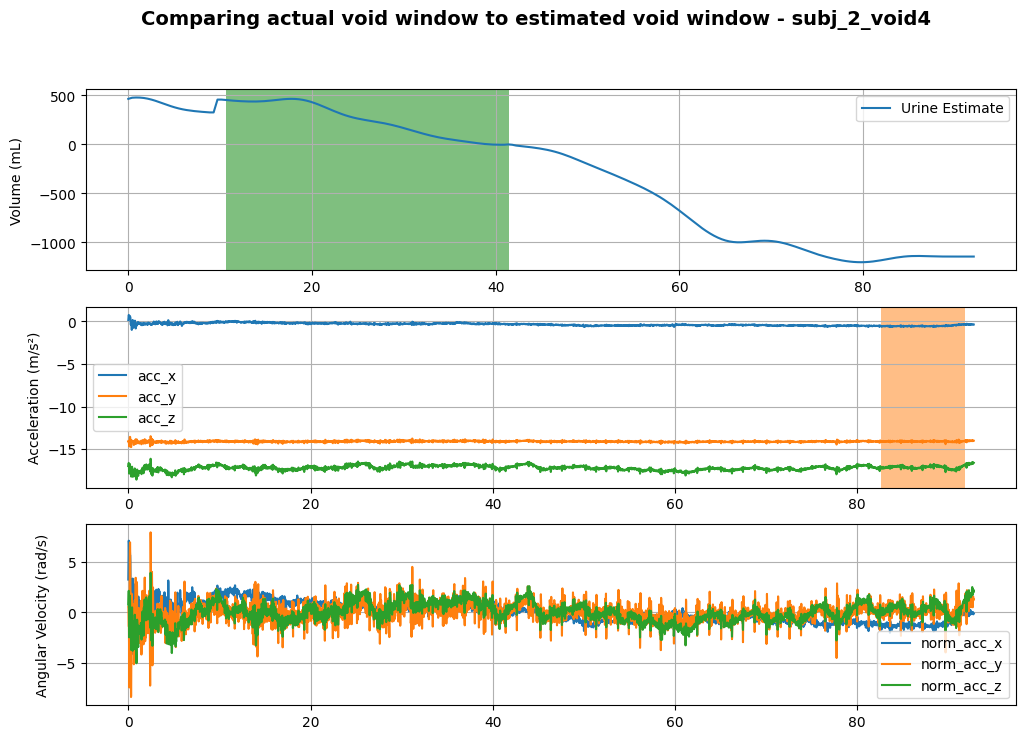

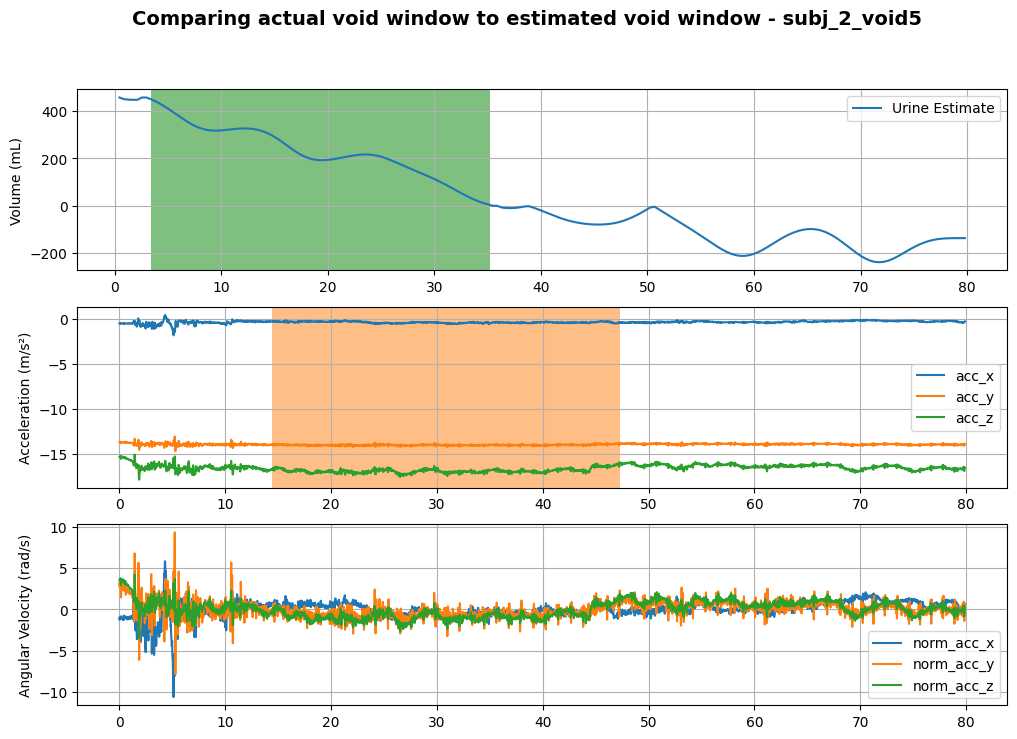

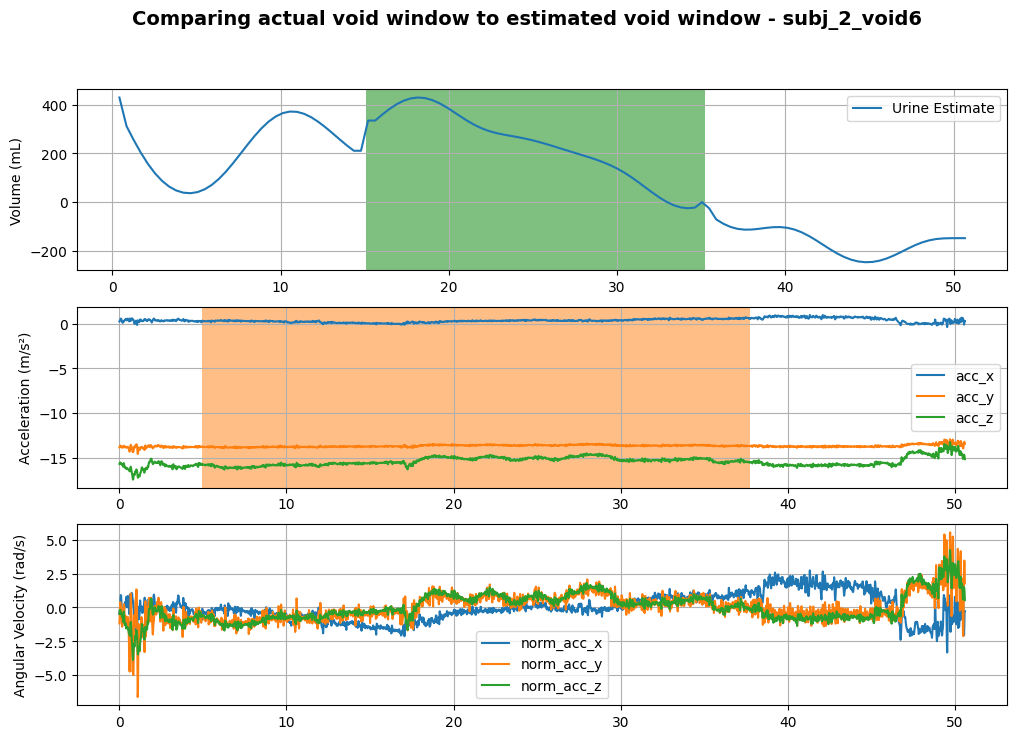

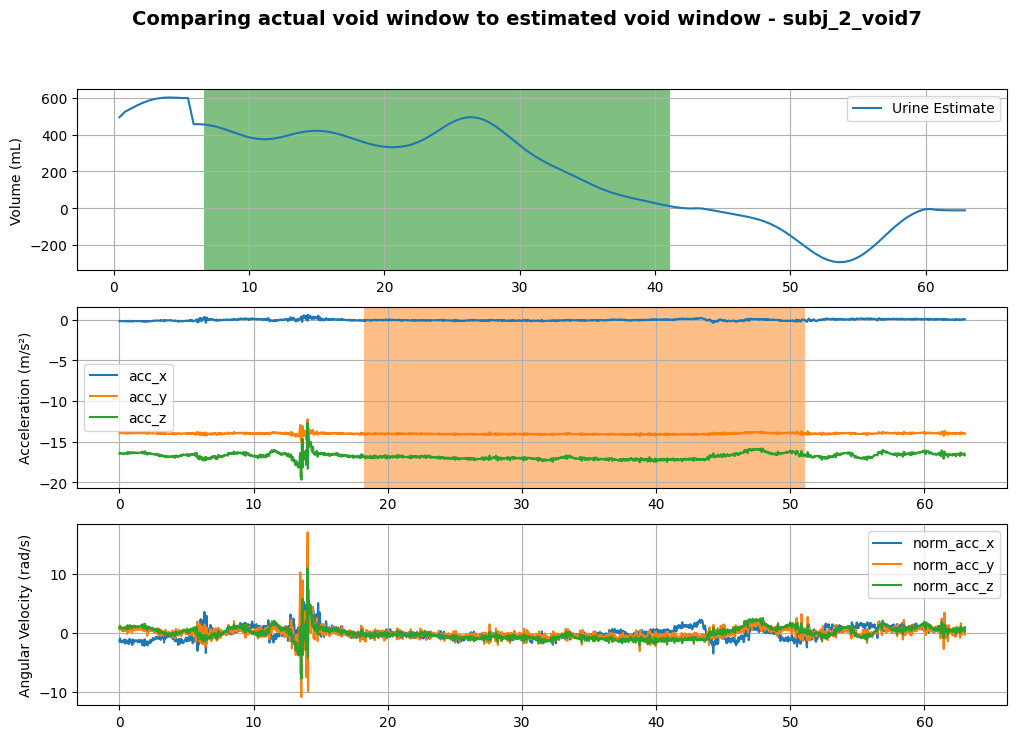

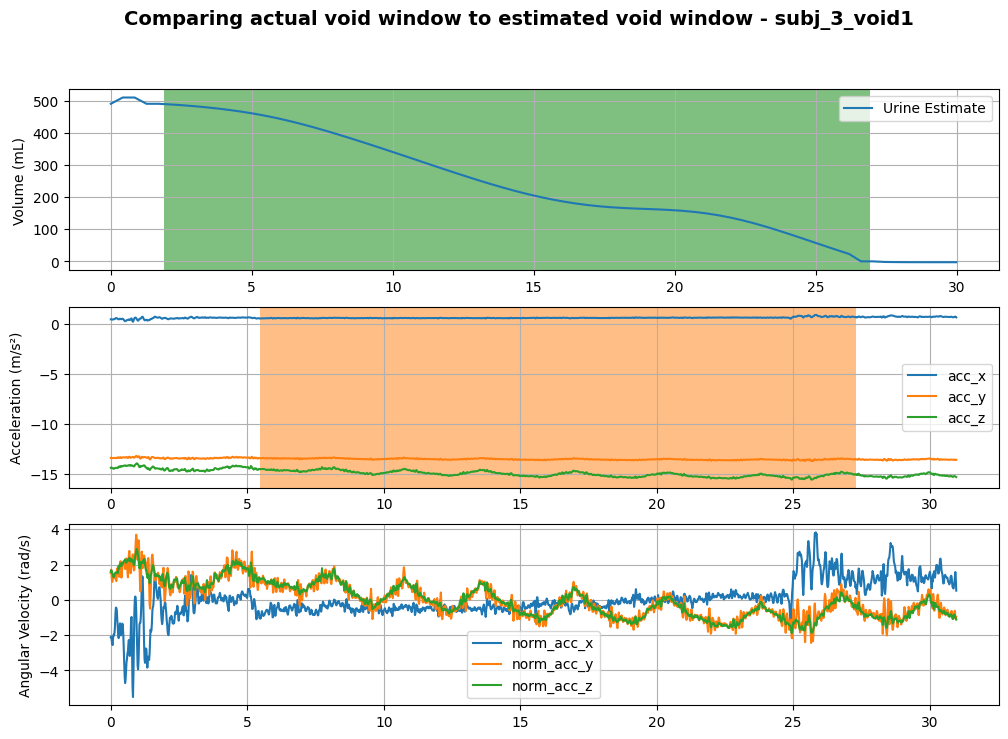

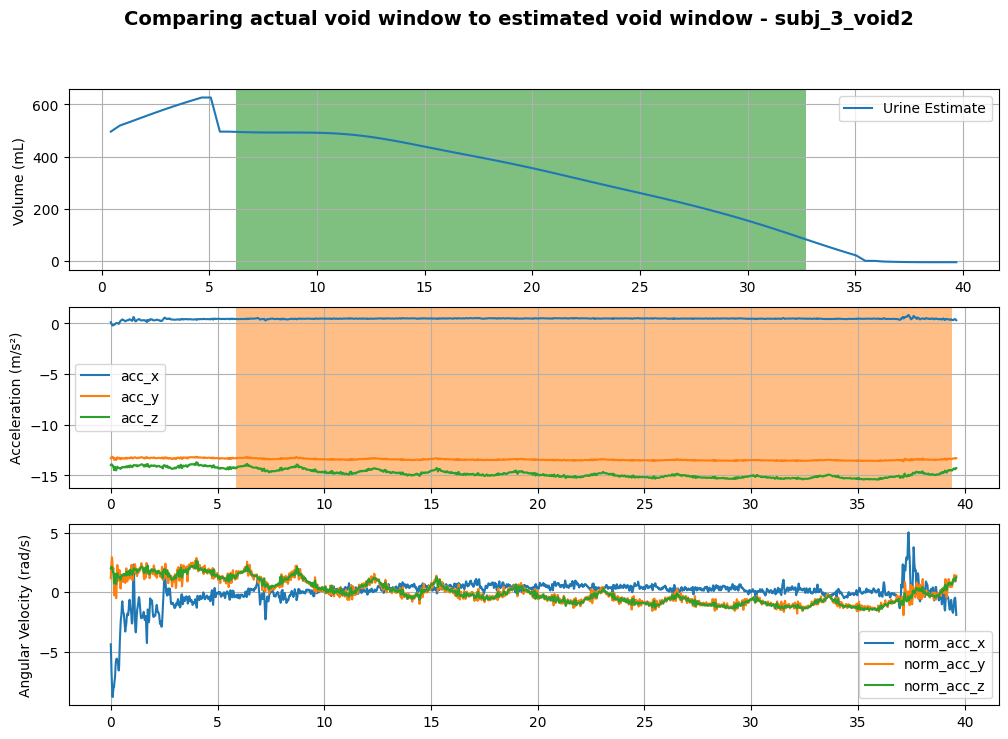

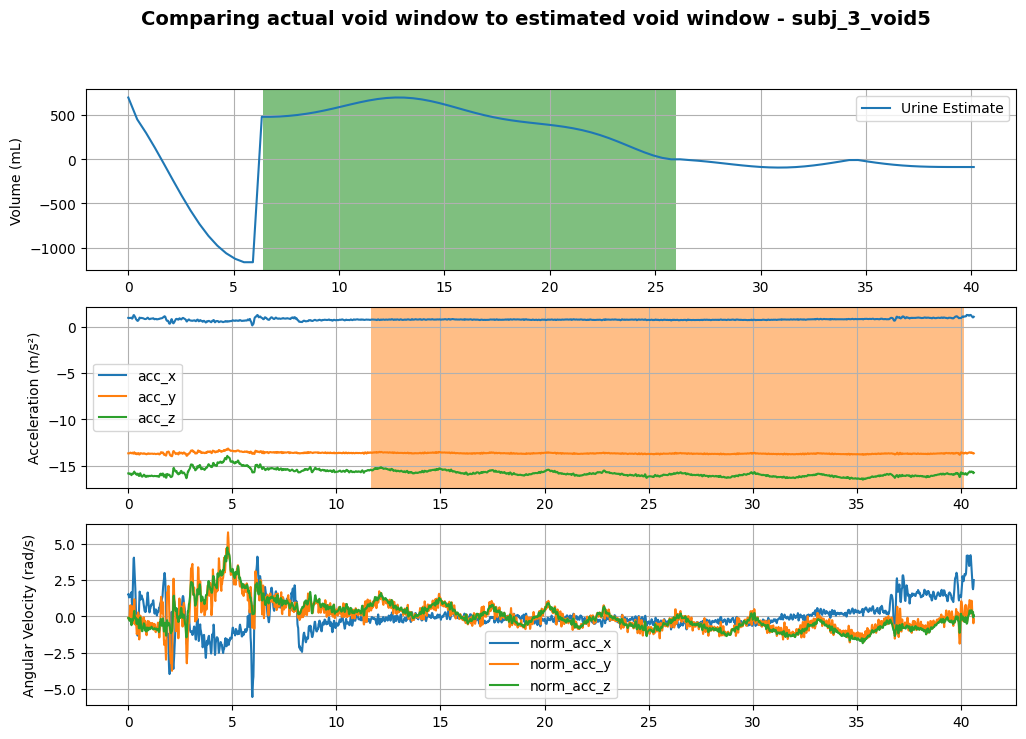

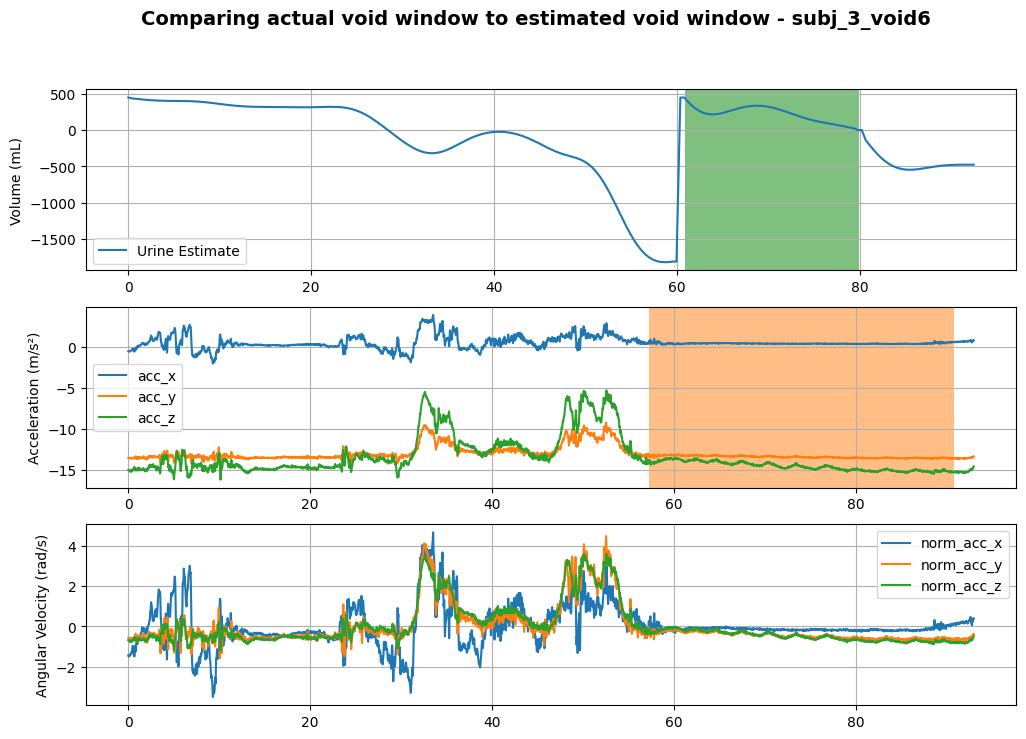

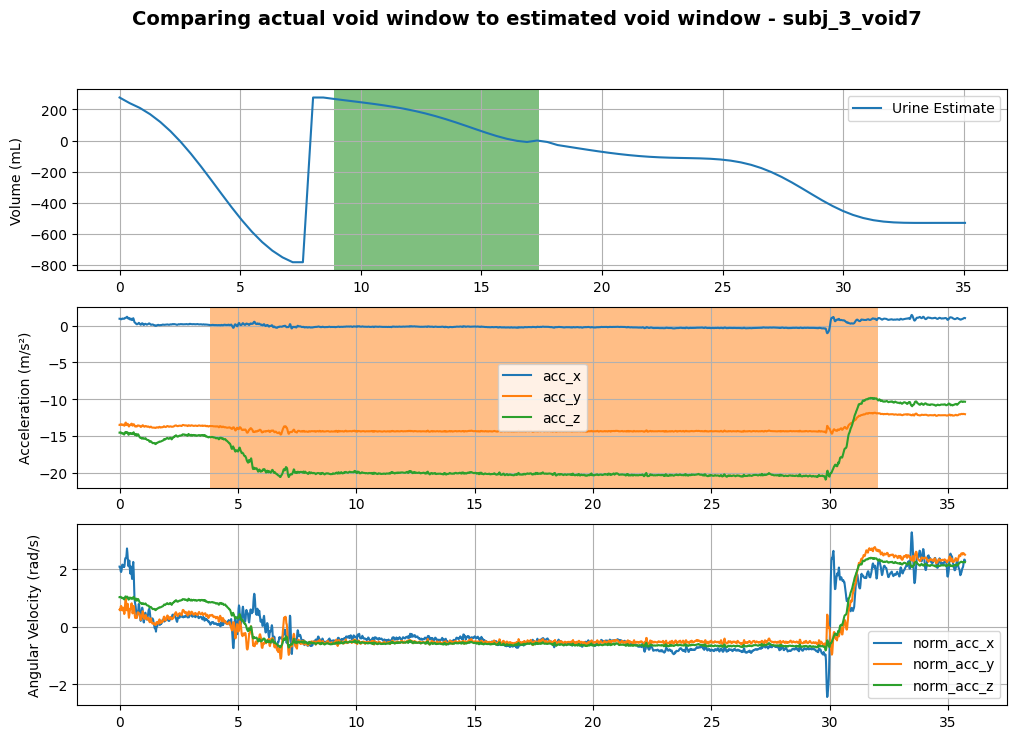

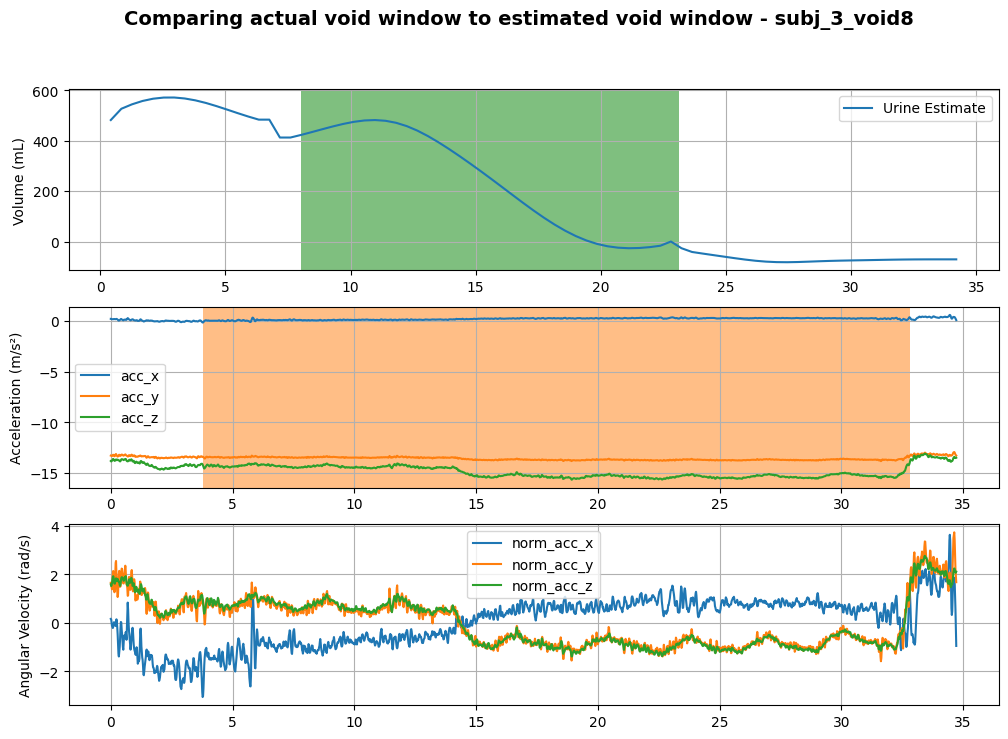

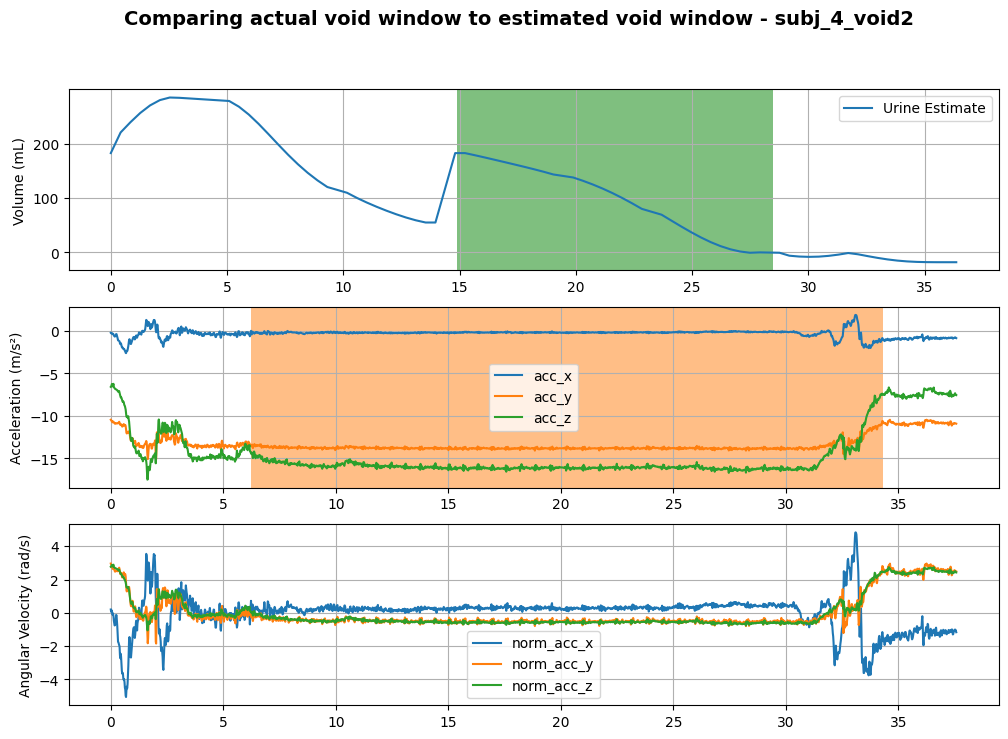

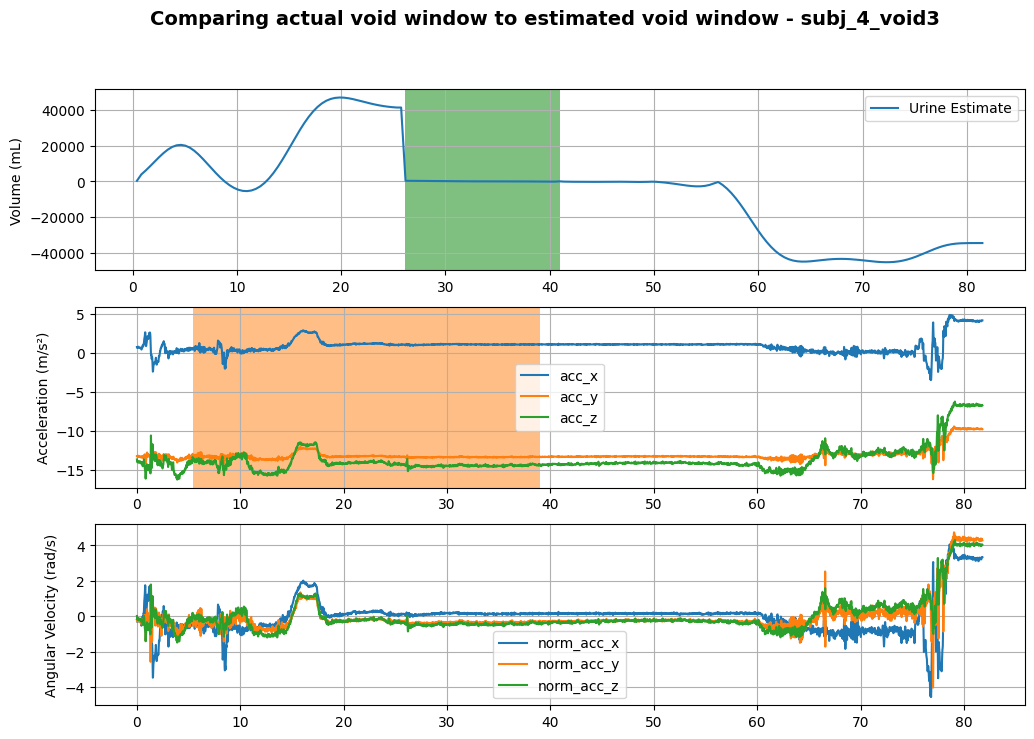

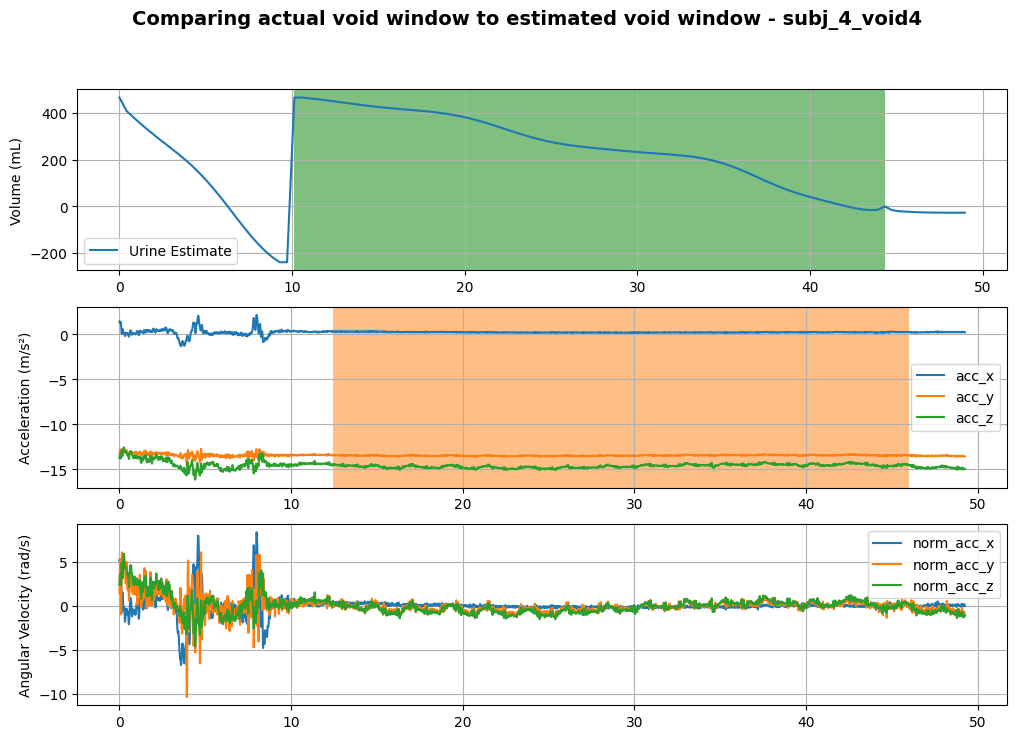

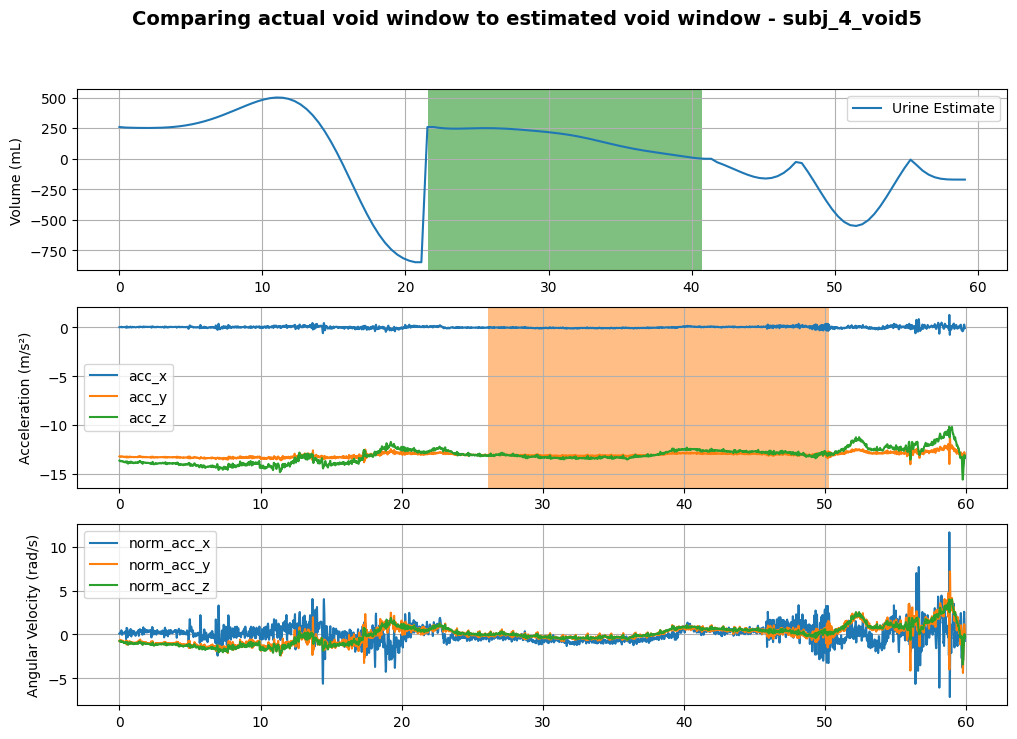

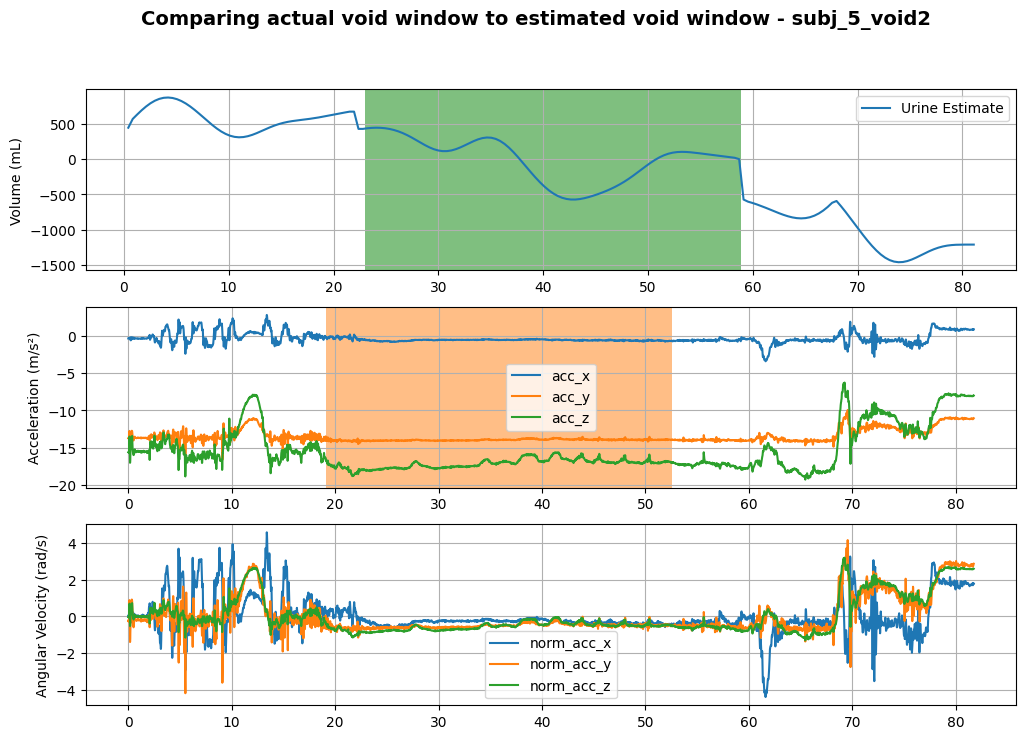

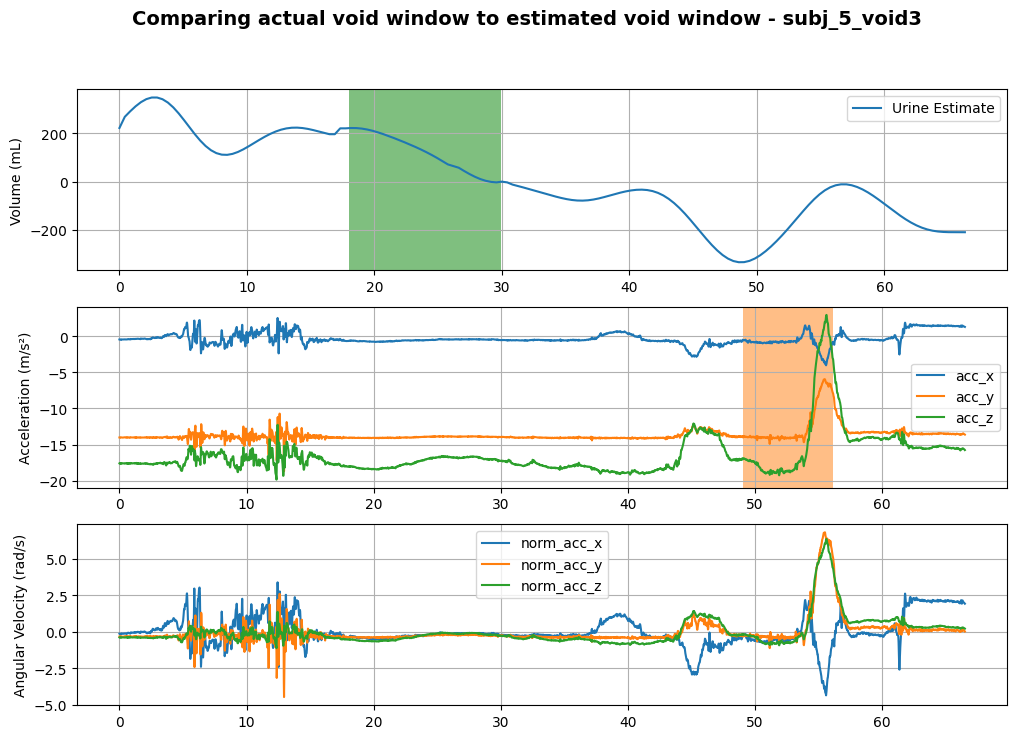

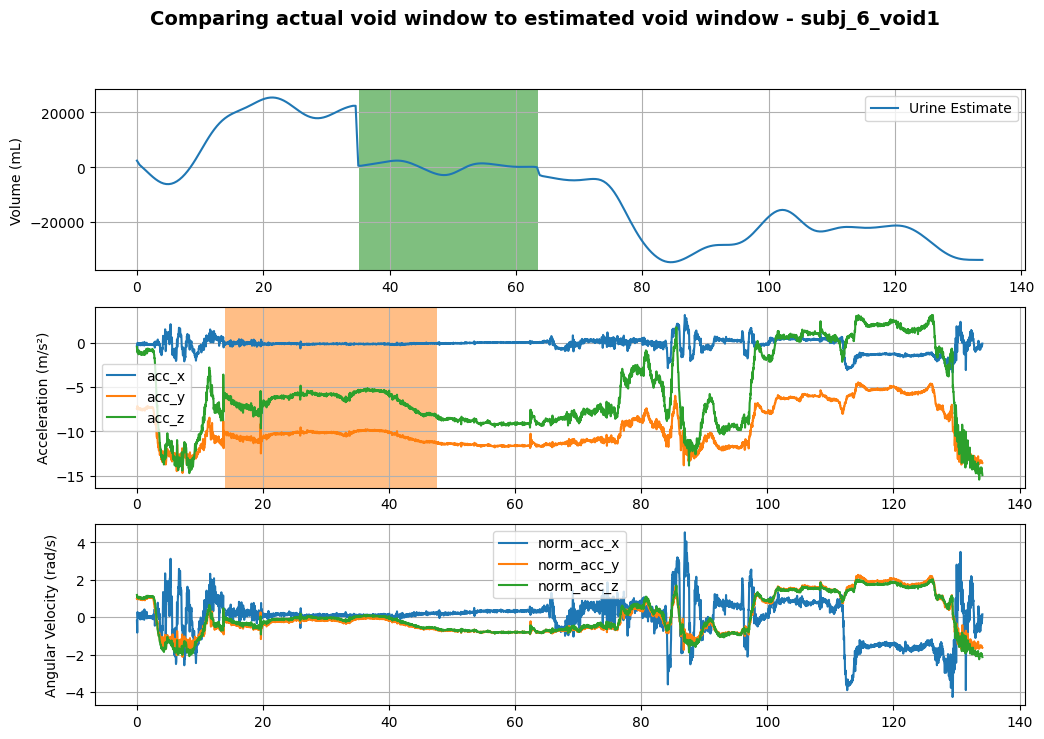

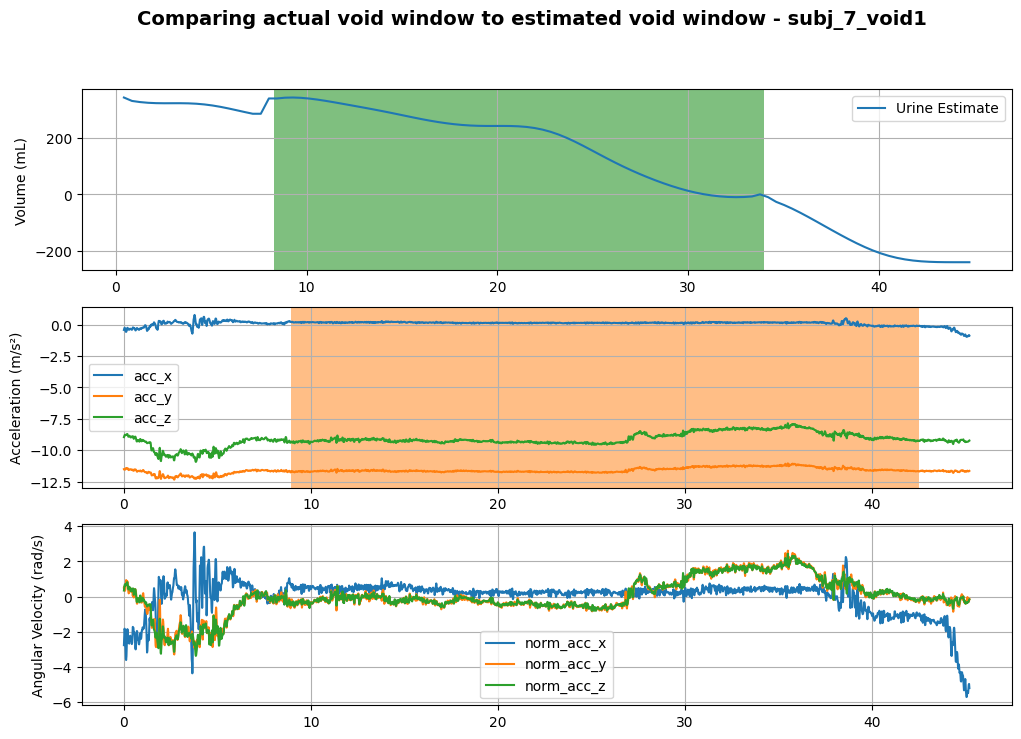

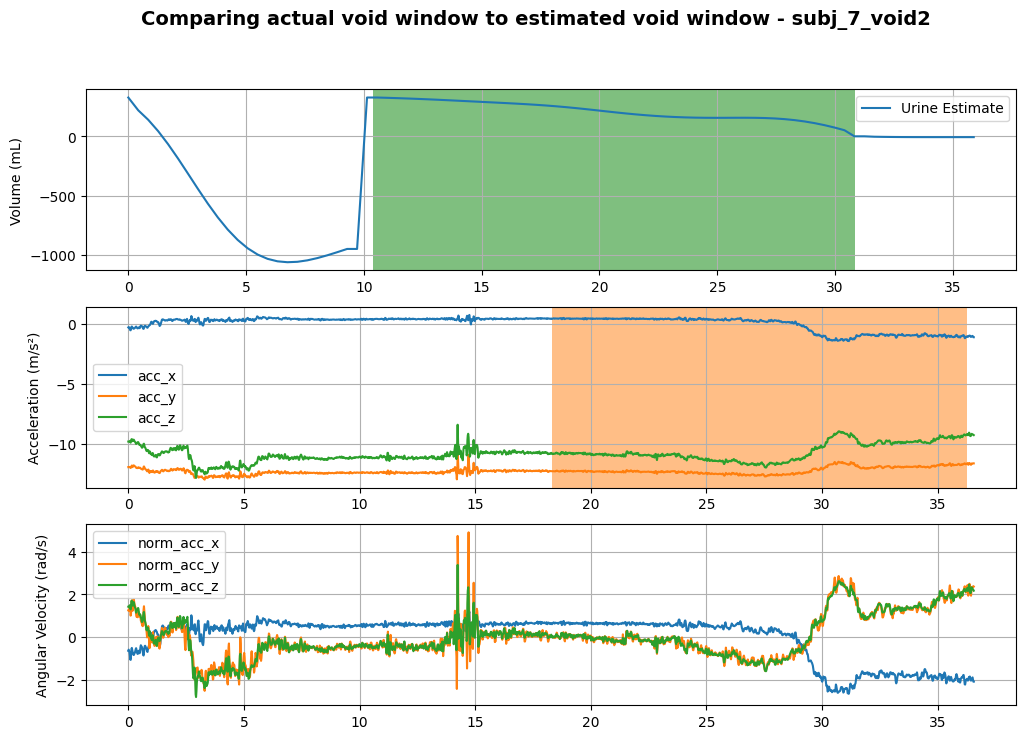

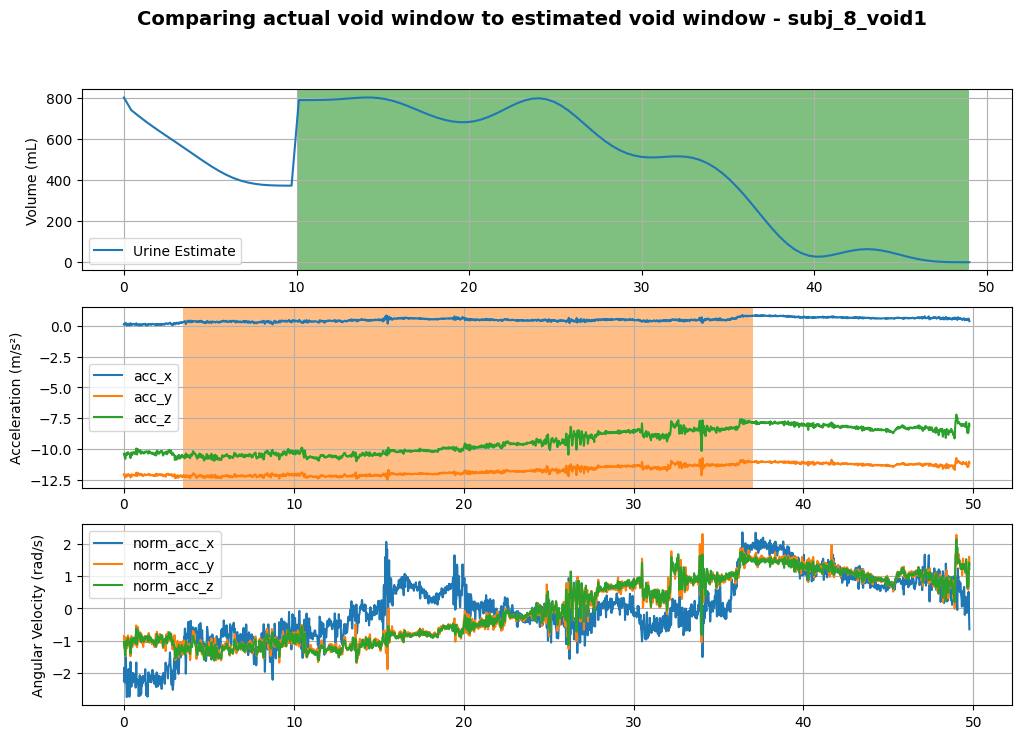

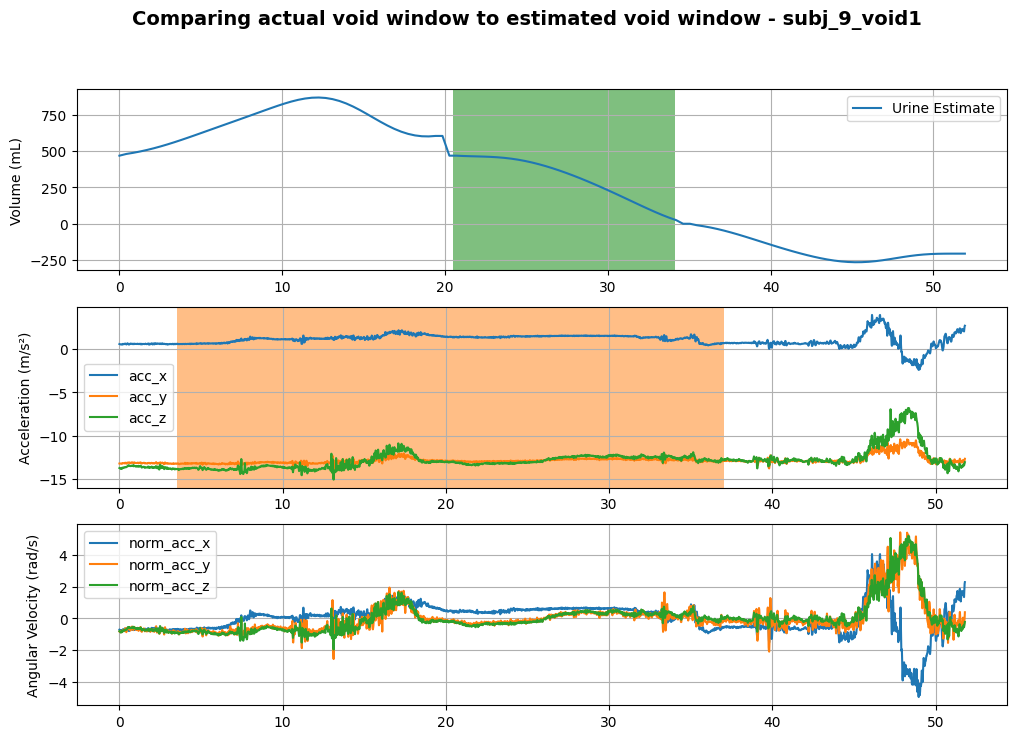

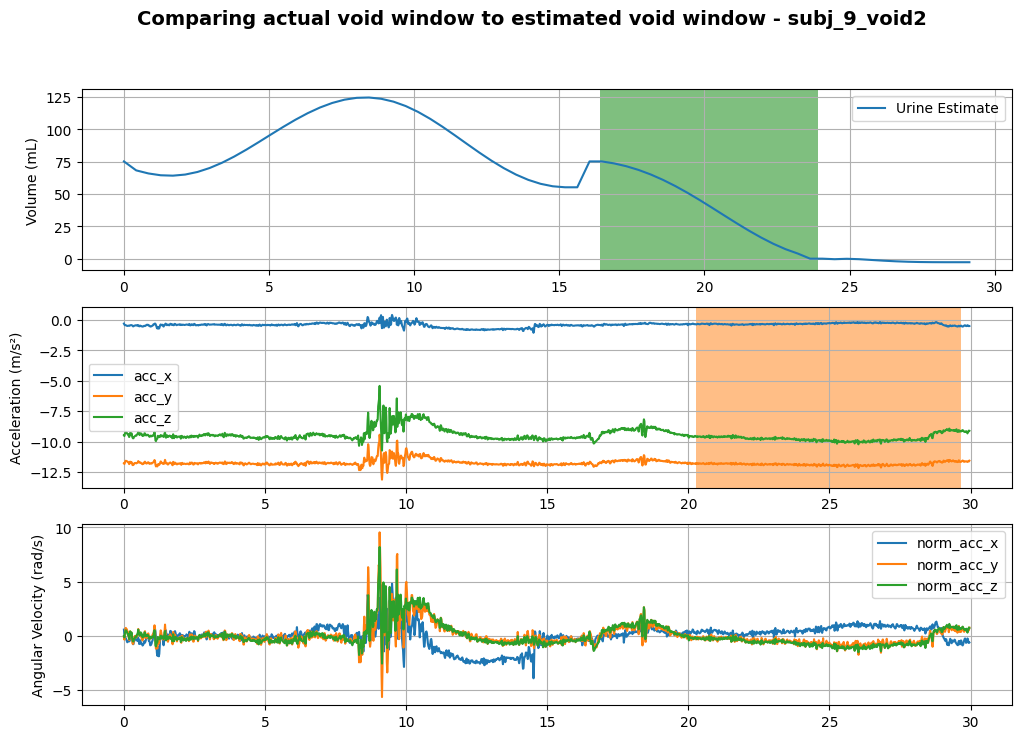

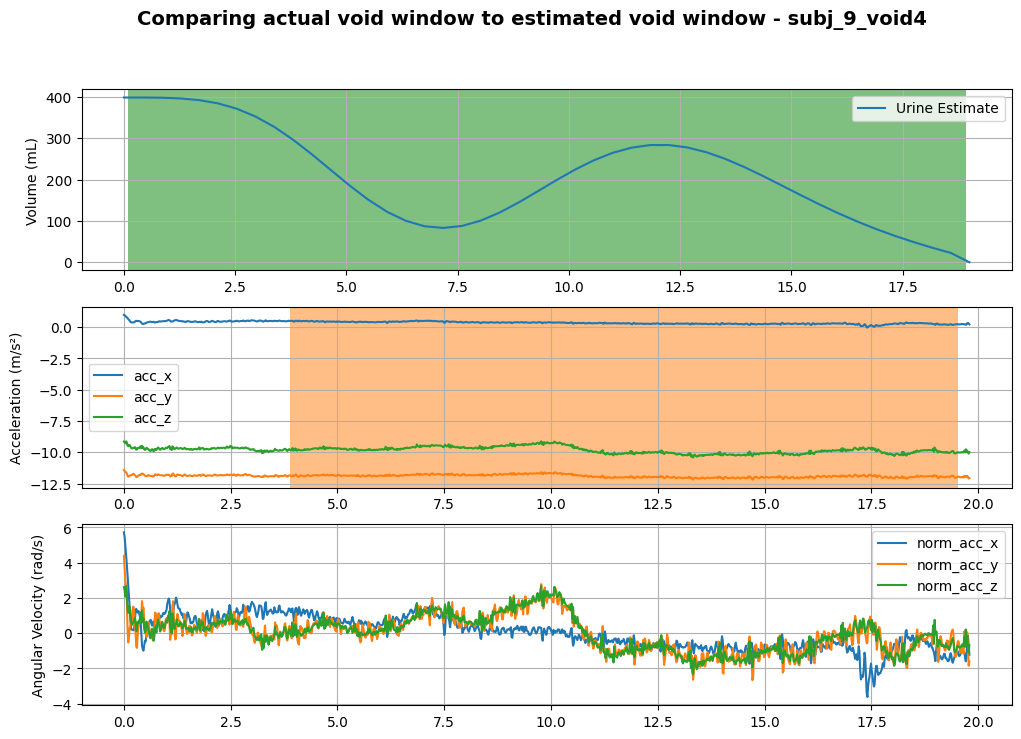

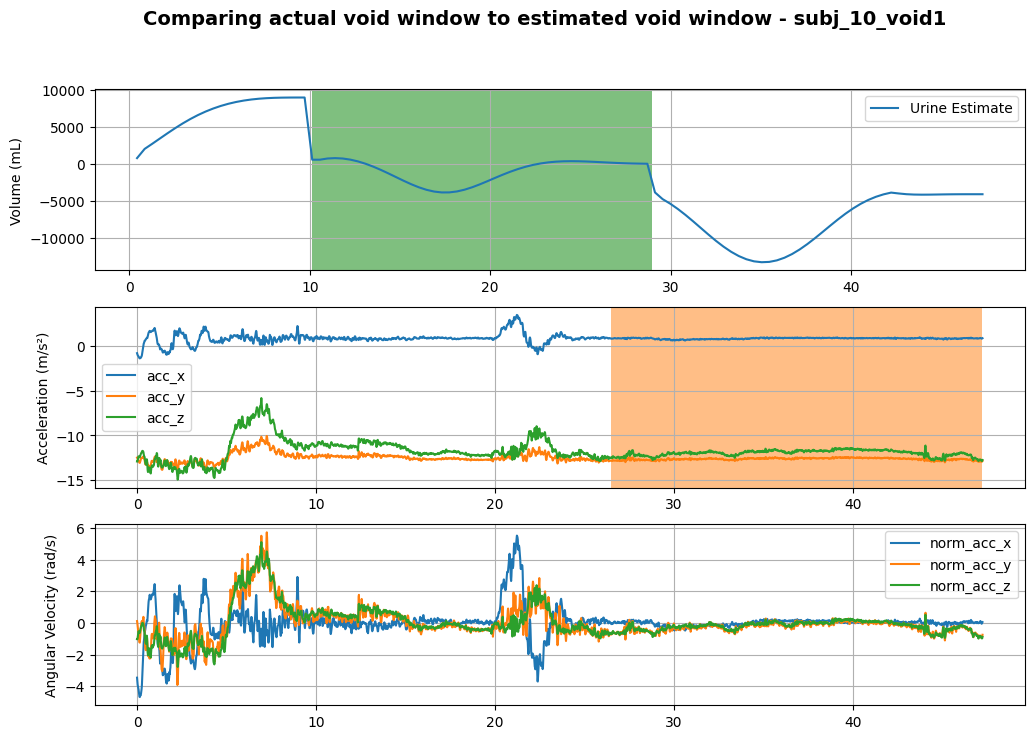

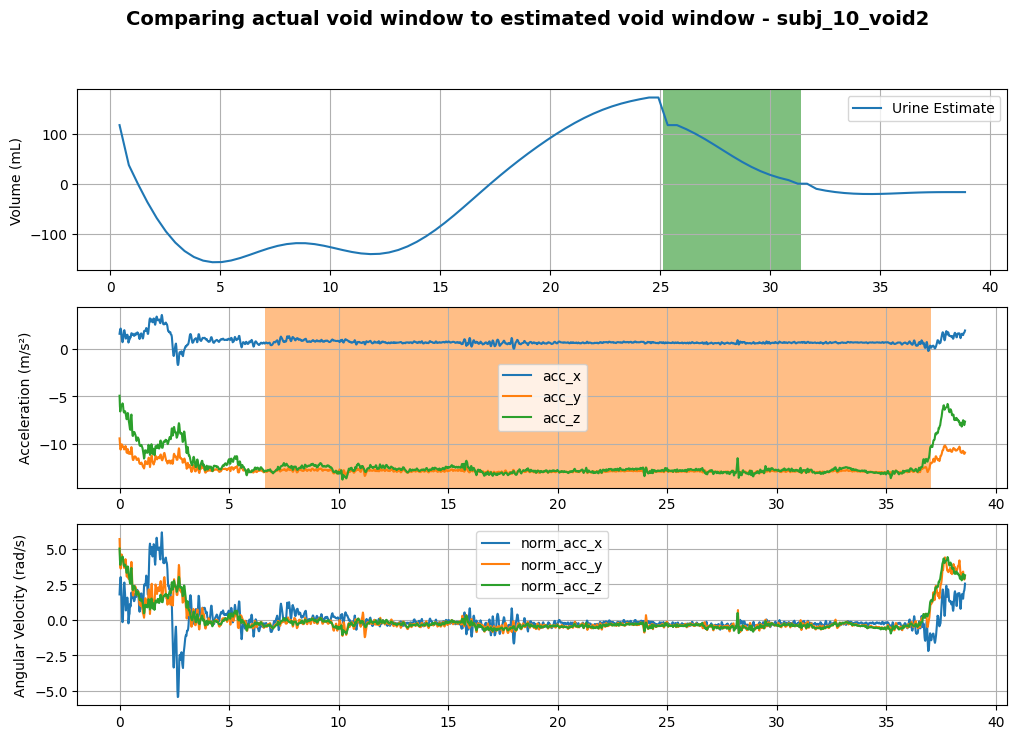

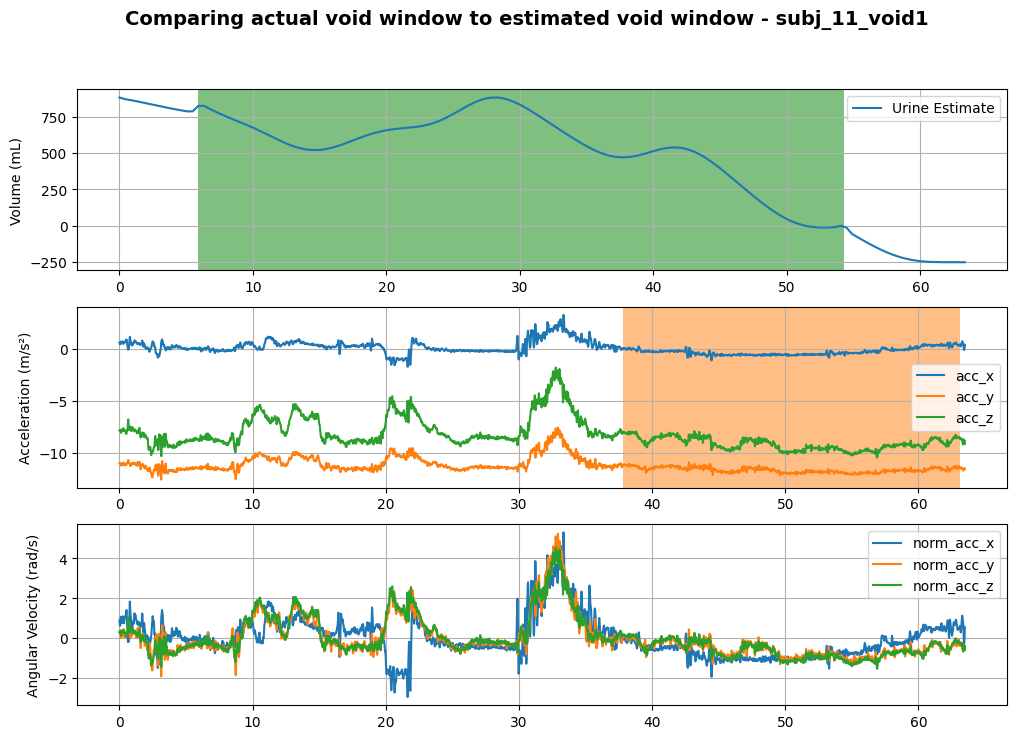

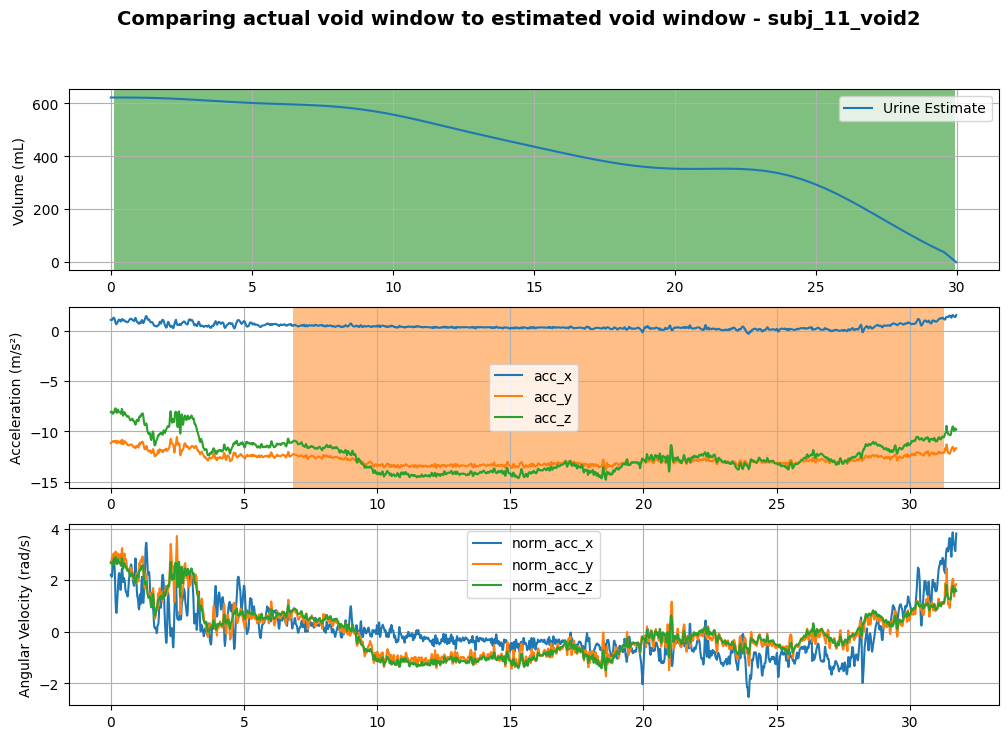

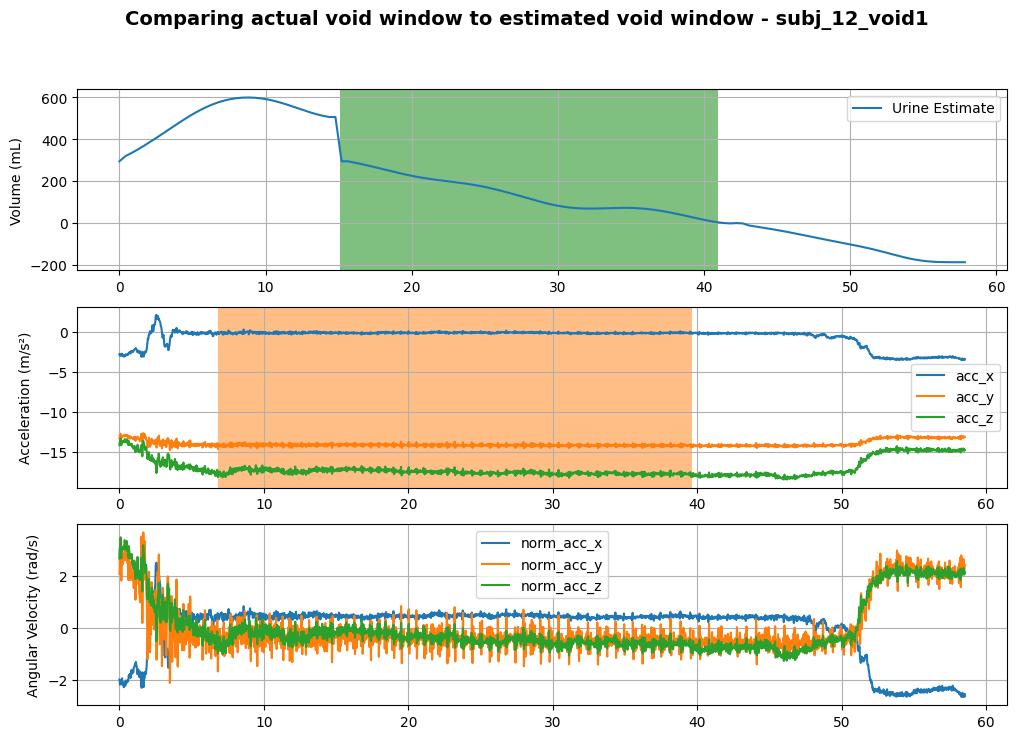

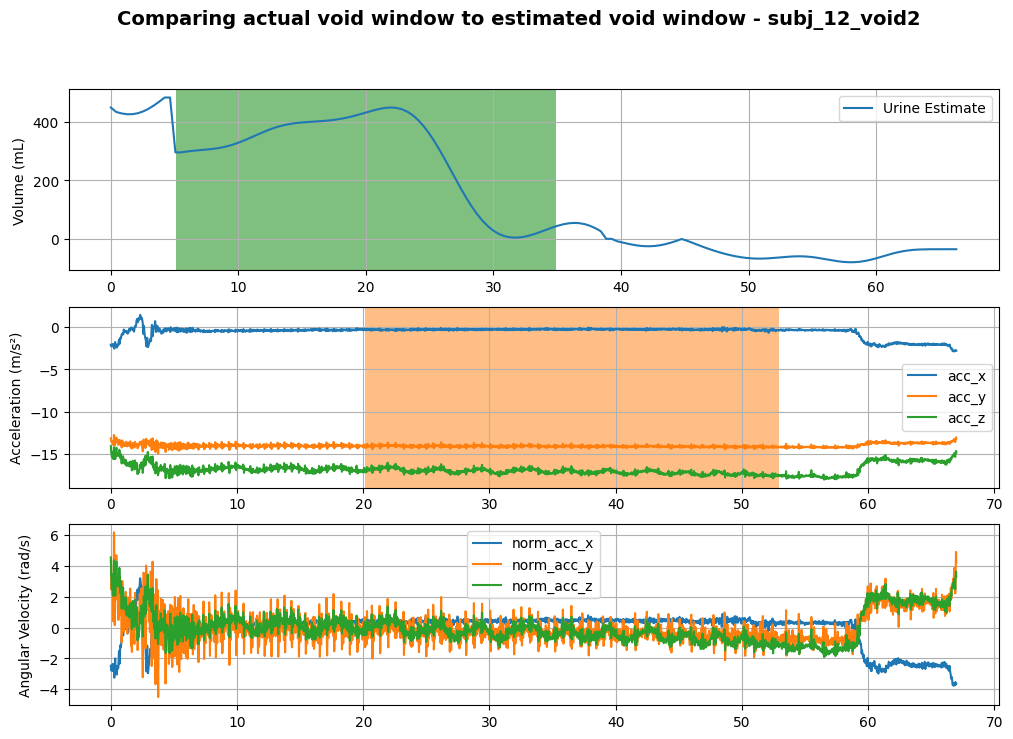

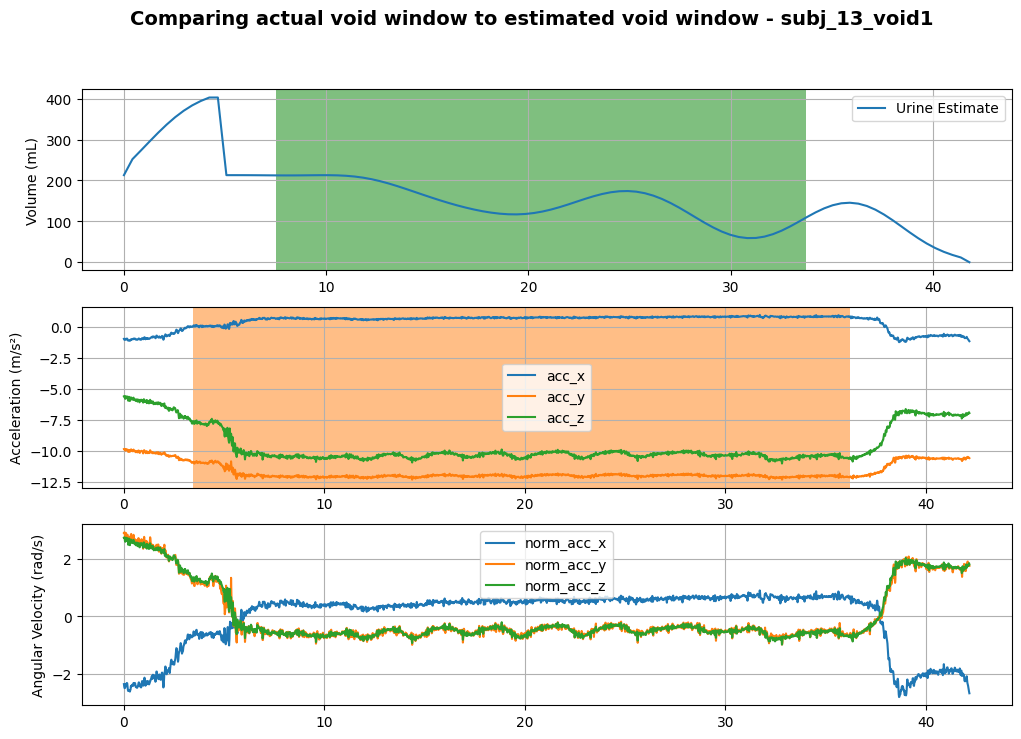

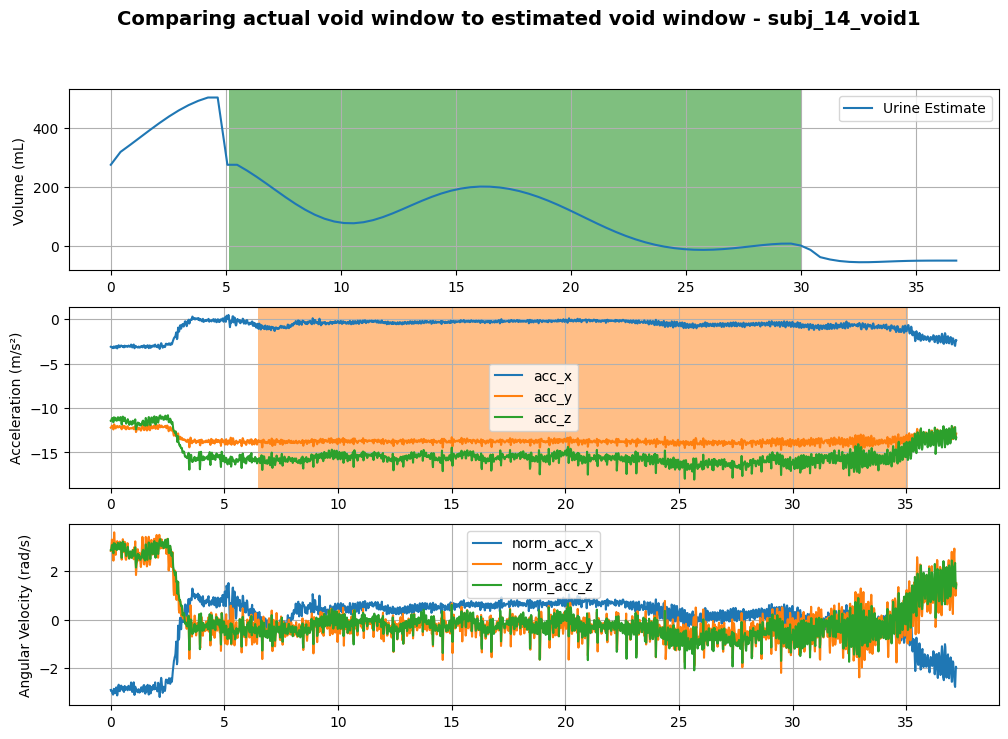

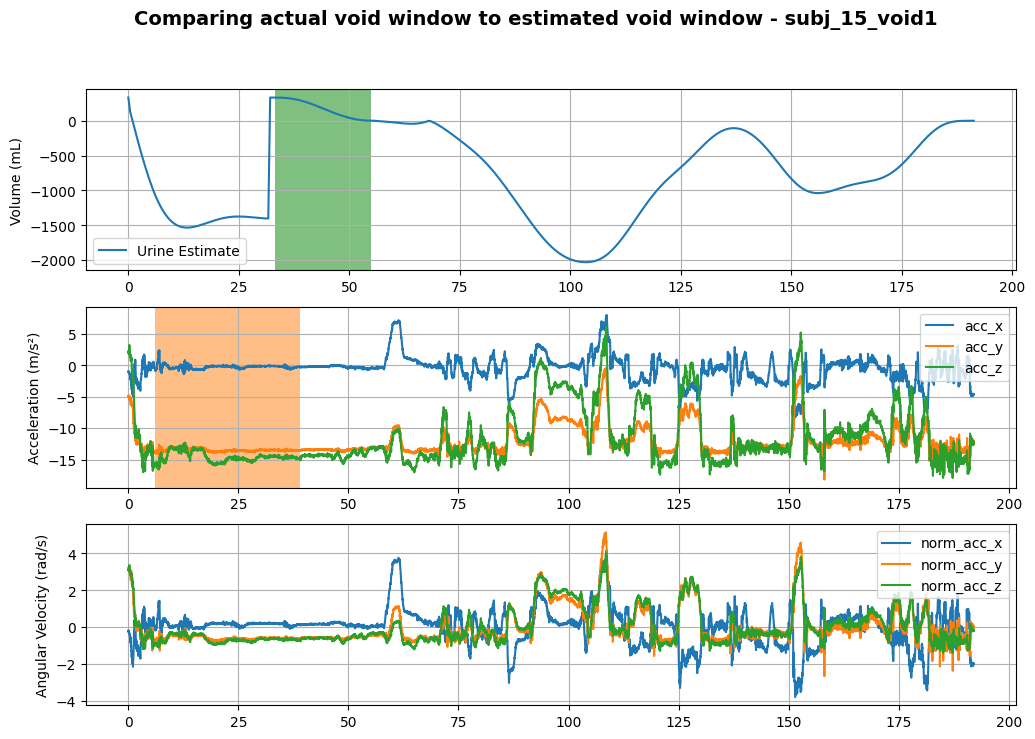

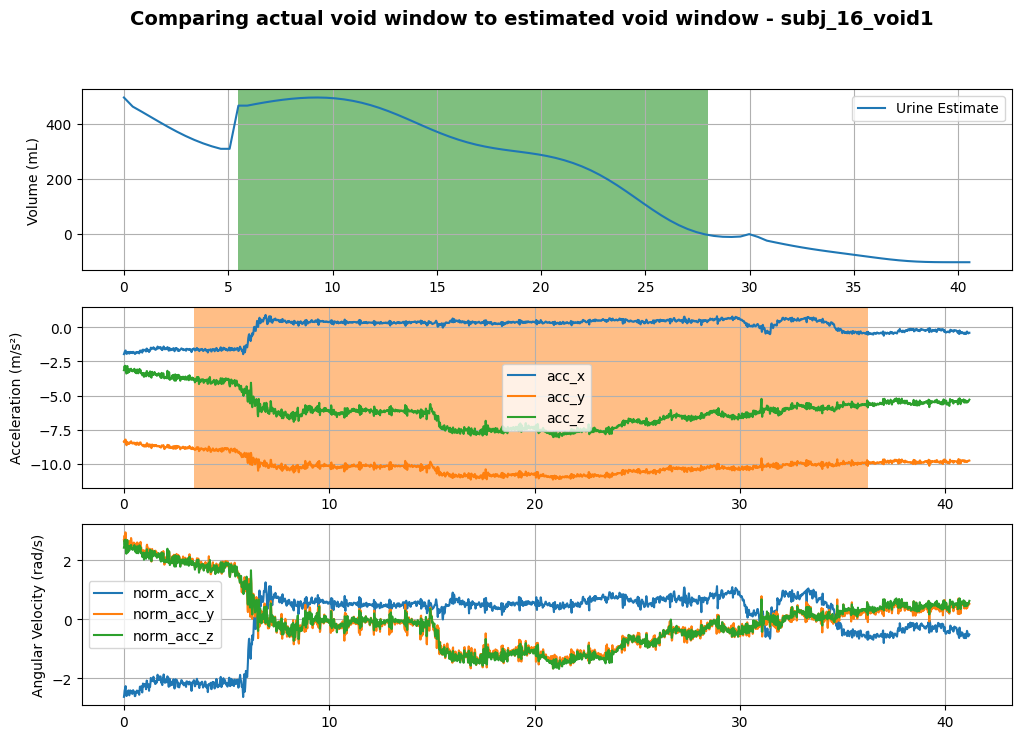

In [ ]:
# for i, experiment in enumerate(features_per_experiment.keys()):
#     sig = features_per_experiment[experiment]
#     raw_imu = imu_dict[experiment]
#     gt = ground_truth_dict[experiment]
#     ue = urine_estimates_dict[experiment]
    
#     _, void_segment = extract_void_segments(sig, N_seconds=5, M_seconds=3, max_void_duration_seconds=40)
    
    
#     start_time = sig['start_time'][void_segment[0]]
#     end_time = sig['end_time'][void_segment[1]]
    
#     # Urination event is the first and last time of the ground truth data
#     urination_event = [gt['Time'].iloc[0], gt['Time'].iloc[-1]] 
#     # Standardize IMU data
#     acc_x_norm = (raw_imu['acc_x'] - raw_imu['acc_x'].mean()) / raw_imu['acc_x'].std()
#     acc_y_norm = (raw_imu['acc_y'] - raw_imu['acc_y'].mean()) / raw_imu['acc_y'].std()
#     acc_z_norm = (raw_imu['acc_z'] - raw_imu['acc_z'].mean()) / raw_imu['acc_z'].std()


#     # Create a figure with 2 subplots (shared x-axis)
#     fig, (ax_top, ax_bottom, ax_middle) = plt.subplots(3, 1, figsize=(12, 8))
#     fig.suptitle(f'Comparing actual void window to estimated void window - {experiment}', fontsize=14, fontweight='bold')


#     # --- Top subplot: Urine Estimate ---
#     ax_top.plot(ue['Time'], ue['UrineEstimate'], label='Urine Estimate')
#     # ax_top.plot(ground_truth['Time'], ground_truth['Volume'], label='Ground Truth')

#     ax_top.axvspan(urination_event[0], urination_event[1], facecolor='green', alpha=0.5)
#     ax_top.set_ylabel('Volume (mL)')
#     # ax_top.set_title(f'Urine Estimate and IMU Data for {void_instance}')

#     ax_top.legend(loc='best')
#     ax_top.grid(True)

#     # --- Bottom subplot: Accelerometer and Gyroscope ---
#     # Accelerometer
#     ax_bottom.plot(raw_imu['time'], raw_imu['acc_x'], label='acc_x')
#     ax_bottom.plot(raw_imu['time'], raw_imu['acc_y'], label='acc_y')
#     ax_bottom.plot(raw_imu['time'], raw_imu['acc_z'], label='acc_z')
#     ax_bottom.axvspan(start_time, end_time, facecolor='tab:orange', alpha=0.5)
#     ax_bottom.set_ylabel('Acceleration (m/s²)')
#     ax_bottom.legend(loc='best')
#     ax_bottom.grid(True)

#     # Gyroscope (second y-axis)
#     # ax2 = ax_bottom.twinx()
#     ax_middle.plot(raw_imu['time'], acc_x_norm, label='norm_acc_x')
#     ax_middle.plot(raw_imu['time'], acc_y_norm, label='norm_acc_y')
#     ax_middle.plot(raw_imu['time'], acc_z_norm, label='norm_acc_z')
#     ax_middle.set_ylabel('Angular Velocity (rad/s)')
#     ax_middle.legend(loc='best')
#     ax_middle.grid(True)



    


In [ ]:
# sig = features_per_experiment['subj_15_void1']
# raw_imu = imu_dict['subj_15_void1']
# gt = ground_truth_dict['subj_15_void1']
# ue = urine_estimates_dict['subj_15_void1']

In [ ]:
# for i, experiment in enumerate(features_per_experiment.keys()):
#     sig = features_per_experiment[experiment]
    
#     fig = px.scatter(sig, x="center_time", 
#                 y=["acc_x_var", "acc_y_var", "acc_z_var"], 
#                 title=f"Signal var {experiment}")
#     fig.show()

In [ ]:
# def extract_void_segments_improved(df, N=5, M=3, max_void_duration=40):
#     """
#     Detects void segments using a state machine based on acceleration variance.
    
#     Parameters:
#     - df: pandas DataFrame with acc_x_var, acc_y_var, acc_z_var columns
#     - N: number of consecutive void-like frames to enter VOID state
#     - M: number of consecutive non-void frames to exit VOID state
#     - max_void_duration: maximum length of VOID state before forced exit

#     Returns:
#     - updated_df: original DataFrame with a 'state_machine_pred' column
#     - void_segments: list of (start_index, end_index) for void segments
#     - transitions: list of state transitions with index and states
#     """
#     state = 'NON_VOID'
#     previous_state = 'NON_VOID'
#     void_buffer = 0
#     non_void_buffer = 0
#     void_state_duration = 0

#     preds = []
#     void_segments = []
#     transitions = []
#     void_start = None

#     for idx, row in df.iterrows():
#         void_condition = (
#             (row['acc_x_var'] <= 1) and 
#             (row['acc_y_var'] <= 0.5) and 
#             (row['acc_z_var'] <= 0.5)
#         )

#         if state == 'NON_VOID':
#             void_state_duration = 0
#             if void_condition:
#                 if void_buffer == 0:  # First void condition - capture start immediately
#                     void_start = idx
#                 void_buffer += 1
#                 if void_buffer >= N:
#                     previous_state = state
#                     state = 'VOID'
#                     void_buffer = 0
#                     # Record transition
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#             else:
#                 void_buffer = 0
#                 void_start = None
#             preds.append('non-void')

#         elif state == 'VOID':
#             void_state_duration += 1

#             # Forced exit
#             if void_state_duration > max_void_duration:
#                 previous_state = state
#                 state = 'NON_VOID'
#                 non_void_buffer = 0
#                 void_segments.append((void_start, idx))
#                 transitions.append({
#                     'index': idx,
#                     'from_state': previous_state,
#                     'to_state': state
#                 })
#                 void_start = None
#                 preds.append('non-void')
#                 continue

#             if not void_condition:
#                 non_void_buffer += 1
#                 if non_void_buffer >= M:
#                     previous_state = state
#                     state = 'NON_VOID'
#                     non_void_buffer = 0
#                     void_segments.append((void_start, idx))
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#                     void_start = None
#                     void_state_duration = 0
#             else:
#                 non_void_buffer = 0

#             preds.append('void')

#     # Handle case where sequence ends in VOID state
#     if state == 'VOID' and void_start is not None:
#         void_segments.append((void_start, df.index[-1]))

#     # Assign predictions to DataFrame
#     df = df.copy()
#     df['state_machine_pred'] = preds
#     return df, void_segments, transitions


# def get_single_void_window(void_segments, method='longest'):
#     """
#     Extract a single void window from multiple detected segments.
    
#     Parameters:
#     - void_segments: list of (start_index, end_index) tuples
#     - method: 'longest', 'first', 'merged', or 'stop_after_first'
    
#     Returns:
#     - single void window as (start_index, end_index) tuple or None
#     """
#     if not void_segments:
#         return None
    
#     if method == 'first':
#         return void_segments[0]
    
#     elif method == 'longest':
#         return max(void_segments, key=lambda seg: seg[1] - seg[0])
    
#     elif method == 'merged':
#         # Merge segments that are close to each other (within 10 frames)
#         if len(void_segments) == 1:
#             return void_segments[0]
        
#         merged_segments = []
#         current_start, current_end = void_segments[0]
        
#         for start, end in void_segments[1:]:
#             if start - current_end <= 10:  # Close segments - merge
#                 current_end = end
#             else:
#                 merged_segments.append((current_start, current_end))
#                 current_start, current_end = start, end
        
#         merged_segments.append((current_start, current_end))
        
#         # Return the longest merged segment
#         return max(merged_segments, key=lambda seg: seg[1] - seg[0])
    
#     else:
#         raise ValueError(f"Unknown method: {method}")


# def extract_single_void_window(df, N=5, M=3, max_void_duration=40, method='longest'):
#     """
#     Wrapper function that detects void segments and returns a single void window.
    
#     Parameters:
#     - df: pandas DataFrame with acc_x_var, acc_y_var, acc_z_var columns
#     - N: number of consecutive void-like frames to enter VOID state
#     - M: number of consecutive non-void frames to exit VOID state
#     - max_void_duration: maximum length of VOID state before forced exit
#     - method: 'longest', 'first', 'merged', or 'stop_after_first'
    
#     Returns:
#     - updated_df: original DataFrame with predictions
#     - single_void_window: (start_index, end_index) tuple or None
#     - transitions: list of state transitions
#     """
#     if method == 'stop_after_first':
#         # Special case: stop detection after first void segment
#         return extract_void_segments_stop_after_first(df, N, M, max_void_duration)
    
#     # Get all void segments
#     updated_df, void_segments, transitions = extract_void_segments_improved(df, N, M, max_void_duration)
    
#     # Extract single window
#     single_window = get_single_void_window(void_segments, method)
    
#     return updated_df, single_window, transitions


# def extract_void_segments_stop_after_first(df, N=5, M=3, max_void_duration=40):
#     """
#     Modified version that stops detection after finding the first complete void segment.
#     """
#     state = 'NON_VOID'
#     previous_state = 'NON_VOID'
#     void_buffer = 0
#     non_void_buffer = 0
#     void_state_duration = 0

#     preds = []
#     transitions = []
#     void_start = None
#     first_void_found = False

#     for idx, row in df.iterrows():
#         if first_void_found:
#             preds.append('non-void')
#             continue
            
#         void_condition = (
#             (row['acc_x_var'] <= 1) and 
#             (row['acc_y_var'] <= 0.5) and 
#             (row['acc_z_var'] <= 0.5)
#         )

#         if state == 'NON_VOID':
#             void_state_duration = 0
#             if void_condition:
#                 if void_buffer == 0:
#                     void_start = idx
#                 void_buffer += 1
#                 if void_buffer >= N:
#                     previous_state = state
#                     state = 'VOID'
#                     void_buffer = 0
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#             else:
#                 void_buffer = 0
#                 void_start = None
#             preds.append('non-void')

#         elif state == 'VOID':
#             void_state_duration += 1

#             # Forced exit
#             if void_state_duration > max_void_duration:
#                 previous_state = state
#                 state = 'NON_VOID'
#                 non_void_buffer = 0
#                 single_void_window = (void_start, idx)
#                 transitions.append({
#                     'index': idx,
#                     'from_state': previous_state,
#                     'to_state': state
#                 })
#                 first_void_found = True
#                 preds.append('non-void')
#                 continue

#             if not void_condition:
#                 non_void_buffer += 1
#                 if non_void_buffer >= M:
#                     previous_state = state
#                     state = 'NON_VOID'
#                     non_void_buffer = 0
#                     single_void_window = (void_start, idx)
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#                     first_void_found = True
#                     void_state_duration = 0
#             else:
#                 non_void_buffer = 0

#             preds.append('void')

#     # Handle case where sequence ends in VOID state
#     if state == 'VOID' and void_start is not None:
#         single_void_window = (void_start, df.index[-1])
#     elif not first_void_found:
#         single_void_window = None

#     # Assign predictions to DataFrame
#     df = df.copy()
#     df['state_machine_pred'] = preds
#     return df, single_void_window, transitions




In [ ]:
df = features_per_experiment['subj_9_void1']

In [ ]:

# # Method 1: Get the longest void segment
# df, longest_void, transitions = extract_single_void_window(df, method='longest')

# # Method 2: Get the first void segment
# df, first_void, transitions = extract_single_void_window(df, method='first')

# # Method 3: Merge nearby segments and get the longest merged segment
# df, merged_void, transitions = extract_single_void_window(df, method='merged')

# # Method 4: Stop after finding the first complete void segment
# df, first_complete_void, transitions = extract_single_void_window(df, method='stop_after_first')

# # Print transitions
# for transition in transitions:
#     print(f"Index {transition['index']}: {transition['from_state']} -> {transition['to_state']}")

In [ ]:
# first_complete_void

In [ ]:
# longest_void
#

In [ ]:
# single_void_window

# Force transition into non-void(post-void)

In [ ]:
# def extract_void_segments_improved(df, N=5, M=3, max_void_duration=40):
#     """
#     Detects void segments using a state machine based on acceleration variance.
#     Fixed void_start assignment and added transition tracking.
    
#     Parameters:
#     - df: pandas DataFrame with acc_x_var, acc_y_var, acc_z_var columns
#     - N: number of consecutive void-like frames to enter VOID state
#     - M: number of consecutive non-void frames to exit VOID state
#     - max_void_duration: maximum length of VOID state before forced exit

#     Returns:
#     - updated_df: original DataFrame with a 'state_machine_pred' column
#     - void_segments: list of (start_index, end_index) for void segments
#     - transitions: list of state transitions with index and states
#     """
#     state = 'NON_VOID'
#     previous_state = 'NON_VOID'
#     void_buffer = 0
#     non_void_buffer = 0
#     void_state_duration = 0
#     forced_exit_occurred = False  # Flag to prevent future void states

#     preds = []
#     void_segments = []
#     transitions = []
#     void_start = None

#     for idx, row in df.iterrows():
#         void_condition = (
#             (row['acc_x_var'] <= 1) and 
#             (row['acc_y_var'] <= 0.5) and 
#             (row['acc_z_var'] <= 0.5)
#         )

#         if state == 'NON_VOID':
#             void_state_duration = 0
#             # If forced exit occurred, stay in NON_VOID regardless of conditions
#             if not forced_exit_occurred and void_condition:
#                 if void_buffer == 0:  # First void condition - capture start immediately
#                     void_start = idx
#                 void_buffer += 1
#                 if void_buffer >= N:
#                     previous_state = state
#                     state = 'VOID'
#                     void_buffer = 0
#                     # Record transition
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#             else:
#                 void_buffer = 0
#                 void_start = None
#             preds.append('non-void')

#         elif state == 'VOID':
#             void_state_duration += 1

#             # Forced exit
#             if void_state_duration > max_void_duration:
#                 previous_state = state
#                 state = 'NON_VOID'
#                 non_void_buffer = 0
#                 void_segments.append((void_start, idx))
#                 forced_exit_occurred = True  # Set flag to prevent future void states
#                 transitions.append({
#                     'index': idx,
#                     'from_state': previous_state,
#                     'to_state': state,
#                     'reason': 'forced_exit'  # Add reason for clarity
#                 })
#                 void_start = None
#                 preds.append('non-void')
#                 continue

#             if not void_condition:
#                 non_void_buffer += 1
#                 if non_void_buffer >= M:
#                     previous_state = state
#                     state = 'NON_VOID'
#                     non_void_buffer = 0
#                     void_segments.append((void_start, idx))
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#                     void_start = None
#                     void_state_duration = 0
#             else:
#                 non_void_buffer = 0

#             preds.append('void')

#     # Handle case where sequence ends in VOID state
#     if state == 'VOID' and void_start is not None:
#         void_segments.append((void_start, df.index[-1]))

#     # Assign predictions to DataFrame
#     df = df.copy()
#     df['state_machine_pred'] = preds
#     return df, void_segments, transitions


# def get_single_void_window(void_segments, method='longest'):
#     """
#     Extract a single void window from multiple detected segments.
    
#     Parameters:
#     - void_segments: list of (start_index, end_index) tuples
#     - method: 'longest', 'first', 'merged', or 'stop_after_first'
    
#     Returns:
#     - single void window as (start_index, end_index) tuple or None
#     """
#     if not void_segments:
#         return None
    
#     if method == 'first':
#         return void_segments[0]
    
#     elif method == 'longest':
#         return max(void_segments, key=lambda seg: seg[1] - seg[0])
    
#     elif method == 'merged':
#         # Merge segments that are close to each other (within 10 frames)
#         if len(void_segments) == 1:
#             return void_segments[0]
        
#         merged_segments = []
#         current_start, current_end = void_segments[0]
        
#         for start, end in void_segments[1:]:
#             if start - current_end <= 10:  # Close segments - merge
#                 current_end = end
#             else:
#                 merged_segments.append((current_start, current_end))
#                 current_start, current_end = start, end
        
#         merged_segments.append((current_start, current_end))
        
#         # Return the longest merged segment
#         return max(merged_segments, key=lambda seg: seg[1] - seg[0])
    
#     else:
#         raise ValueError(f"Unknown method: {method}")


# def extract_single_void_window(df, N=5, M=3, max_void_duration=40, method='longest'):
#     """
#     Wrapper function that detects void segments and returns a single void window.
    
#     Parameters:
#     - df: pandas DataFrame with acc_x_var, acc_y_var, acc_z_var columns
#     - N: number of consecutive void-like frames to enter VOID state
#     - M: number of consecutive non-void frames to exit VOID state
#     - max_void_duration: maximum length of VOID state before forced exit
#     - method: 'longest', 'first', 'merged', or 'stop_after_first'
    
#     Returns:
#     - updated_df: original DataFrame with predictions
#     - single_void_window: (start_index, end_index) tuple or None
#     - transitions: list of state transitions
#     """
#     if method == 'stop_after_first':
#         # Special case: stop detection after first void segment
#         return extract_void_segments_stop_after_first(df, N, M, max_void_duration)
    
#     # Get all void segments
#     updated_df, void_segments, transitions = extract_void_segments_improved(df, N, M, max_void_duration)
    
#     # Extract single window
#     single_window = get_single_void_window(void_segments, method)
    
#     return updated_df, single_window, transitions


# def extract_void_segments_stop_after_first(df, N=5, M=3, max_void_duration=40):
#     """
#     Modified version that stops detection after finding the first complete void segment.
#     """
#     state = 'NON_VOID'
#     previous_state = 'NON_VOID'
#     void_buffer = 0
#     non_void_buffer = 0
#     void_state_duration = 0
#     forced_exit_occurred = False  # Flag to prevent future void states

#     preds = []
#     transitions = []
#     void_start = None
#     first_void_found = False

#     for idx, row in df.iterrows():
#         if first_void_found:
#             preds.append('non-void')
#             continue
            
#         void_condition = (
#             (row['acc_x_var'] <= 1) and 
#             (row['acc_y_var'] <= 0.5) and 
#             (row['acc_z_var'] <= 0.5)
#         )

#         if state == 'NON_VOID':
#             void_state_duration = 0
#             # If forced exit occurred or first void already found, stay in NON_VOID
#             if not forced_exit_occurred and not first_void_found and void_condition:
#                 if void_buffer == 0:
#                     void_start = idx
#                 void_buffer += 1
#                 if void_buffer >= N:
#                     previous_state = state
#                     state = 'VOID'
#                     void_buffer = 0
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#             else:
#                 void_buffer = 0
#                 void_start = None
#             preds.append('non-void')

#         elif state == 'VOID':
#             void_state_duration += 1

#             # Forced exit
#             if void_state_duration > max_void_duration:
#                 previous_state = state
#                 state = 'NON_VOID'
#                 non_void_buffer = 0
#                 single_void_window = (void_start, idx)
#                 forced_exit_occurred = True  # Set flag to prevent future void states
#                 transitions.append({
#                     'index': idx,
#                     'from_state': previous_state,
#                     'to_state': state,
#                     'reason': 'forced_exit'
#                 })
#                 first_void_found = True
#                 preds.append('non-void')
#                 continue

#             if not void_condition:
#                 non_void_buffer += 1
#                 if non_void_buffer >= M:
#                     previous_state = state
#                     state = 'NON_VOID'
#                     non_void_buffer = 0
#                     single_void_window = (void_start, idx)
#                     transitions.append({
#                         'index': idx,
#                         'from_state': previous_state,
#                         'to_state': state
#                     })
#                     first_void_found = True
#                     void_state_duration = 0
#             else:
#                 non_void_buffer = 0

#             preds.append('void')

#     # Handle case where sequence ends in VOID state
#     if state == 'VOID' and void_start is not None:
#         single_void_window = (void_start, df.index[-1])
#     elif not first_void_found:
#         single_void_window = None

#     # Assign predictions to DataFrame
#     df = df.copy()
#     df['state_machine_pred'] = preds
#     return df, single_void_window, transitions




In [ ]:
# df = features_per_experiment['subj_4_void3']

In [ ]:
# # Example usage:

# # Method 1: Get the longest void segment
# df, longest_void, transitions = extract_single_void_window(df, method='longest')

# # Method 2: Get the first void segment
# df, first_void, transitions = extract_single_void_window(df, method='first')

# # Method 3: Merge nearby segments and get the longest merged segment
# df, merged_void, transitions = extract_single_void_window(df, method='merged')

# # Method 4: Stop after finding the first complete void segment
# df, first_complete_void, transitions = extract_single_void_window(df, method='stop_after_first')

# # Print transitions
# for transition in transitions:
#     print(f"Index {transition['index']}: {transition['from_state']} -> {transition['to_state']}")


In [ ]:
# longest_void

In [ ]:
# transitions